  ## Import Libraries

We import the core libraries needed:
- **pandas / numpy**: for data manipulation.
- **matplotlib / seaborn**: for plotting and visualization.
#

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


##  Load the Data



In [ ]:
from google.colab import files
uploaded = files.upload()
df=pd.read_csv("bank.csv")
print("Data shape :", df.shape)
df.head(50)

Saving bank.csv to bank (5).csv
Data shape : (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes
6,56,management,married,tertiary,no,830,yes,yes,unknown,6,may,1201,1,-1,0,unknown,yes
7,60,retired,divorced,secondary,no,545,yes,no,unknown,6,may,1030,1,-1,0,unknown,yes
8,37,technician,married,secondary,no,1,yes,no,unknown,6,may,608,1,-1,0,unknown,yes
9,28,services,single,secondary,no,5090,yes,no,unknown,6,may,1297,3,-1,0,unknown,yes


## Column Overview and Data Types

`df.info()` shows us:
- Each column's name.
- The number of non-null values.
- The data type (numeric, text, etc.).



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


#Check Missing Values

This dataset usually has no real NaN values, but categorical columns such as `job`, `education`, `contact`, and `poutcome` often contain the value `unknown` instead of a real category — effectively a "disguised" missing value. We check both:
1. The count of actual NaN values per column.
2. The count of `unknown` values in categorical columns.

In [ ]:
# 1. Real missing values (NaN)
print("Missing values (NaN) :")
print(df.isnull().sum())

# 2. Count of "unknown" values in text columns
print("\nCount of 'unknown' values per categorical column:")
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    unknown_count = (df[col] == "unknown").sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} ({unknown_count/len(df)*100:.1f}%)")

Missing values (NaN) :
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Count of 'unknown' values per categorical column:
job: 70 (0.6%)
education: 497 (4.5%)
contact: 2346 (21.0%)
poutcome: 8326 (74.6%)


# Check Duplicate Rows

We make sure there are no fully duplicated rows that could bias the analysis or a future model.

In [ ]:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0




# Categorical Variables
The dataset contains several categorical variables such as job, marital status, education, housing, loan, and contact type.
In this step, we identify the categorical columns that will require further analysis and encoding before Machine Learning.

In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')


# Descriptive Statistics for Numerical Columns
`describe()` gives us the mean, standard deviation, min, max, and quartiles (25%, 50%, 75%) for each numerical column such as `age`, `balance`, `duration`, `campaign`, `pdays`, `previous`.

This helps us spot potential outliers early on — for example, `balance` may contain negative or unusually large values. We also set `display.max_columns` to `None` just for this one printout, so the transposed table isn't truncated.

In [ ]:
pd.set_option("display.max_columns", None)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,11162.0,41.231948,11.913369,18.0,32.0,39.0,49.00,95.0
balance,11162.0,1528.538524,3225.413326,-6847.0,122.0,550.0,1708.00,81204.0
day,11162.0,15.658036,8.420740,1.0,8.0,15.0,22.00,31.0
duration,11162.0,371.993818,347.128386,2.0,138.0,255.0,496.00,3881.0
campaign,11162.0,2.508421,2.722077,1.0,1.0,2.0,3.00,63.0
pdays,11162.0,51.330407,108.758282,-1.0,-1.0,-1.0,20.75,854.0
previous,11162.0,0.832557,2.292007,0.0,0.0,0.0,1.00,58.0


# Descriptive Statistics for Categorical Columns
Here we look at the number of unique values in each text column, along with the most frequent value (top) and its frequency (freq).

In [ ]:
# Show descriptive statistics for text/object columns only: count, unique, top, freq
# .T transposes the result so each text column becomes a row and stats become columns (easier to read)
df.describe(include="object").T

,count,unique,top,freq
job,11162,12,management,2566
marital,11162,3,married,6351
education,11162,4,secondary,5476
default,11162,2,no,10994
housing,11162,2,no,5881
loan,11162,2,no,9702
contact,11162,3,cellular,8042
month,11162,12,may,2824
poutcome,11162,4,unknown,8326
deposit,11162,2,no,5873


# Duration — Kept Intentionally (Post-Call Feature)
#`duration` is only known after/during the call, so a model that includes it
#is a "post-call" model, not a realistic pre-call predictor. We keep it here
#deliberately for stronger performance, and we note this trade-off clearly
#when reporting results.


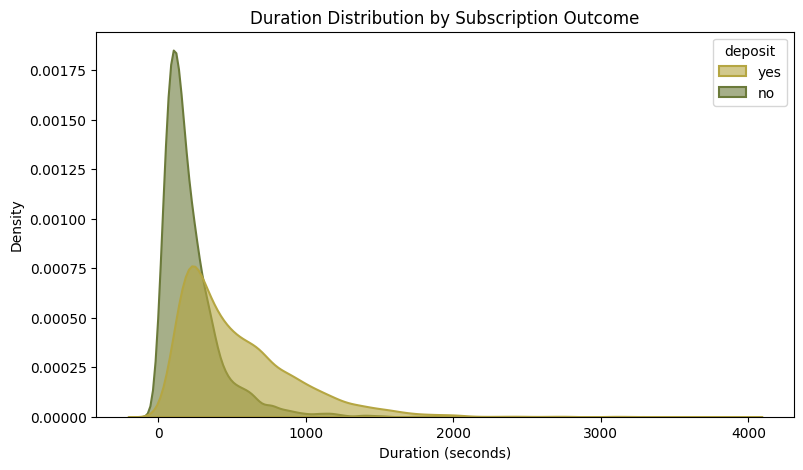

Correlation value: 0.4519193608425855


In [ ]:


# Duration Distribution by Subscription Outcome — Olive Tones

olive_colors = {"no": "#6B7A3A", "yes": "#B5A642"}  # olive green + mustard/olive-gold

plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x="duration", hue="deposit", fill=True,
            palette=olive_colors, alpha=0.6, linewidth=1.5)

plt.title("Duration Distribution by Subscription Outcome")
plt.xlabel("Duration (seconds)")
plt.ylabel("Density")
plt.show()

print("Correlation value:", df[["duration", "deposit"]].assign(
    deposit=lambda d: d["deposit"].map({"yes": 1, "no": 0})
).corr().loc["duration", "deposit"])

# Fix pdays: -1 is a sentinel value meaning "never contacted before",
 not a real number of days. We create a separate flag for this
 and replace -1 with 0 so it doesn't distort scaling later.

In [ ]:
df["was_contacted_before"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

# Target Variable Distribution — `deposit`

 check whether the sample is balanced between `yes` and `no`, or whether there is class imbalance. This matters a lot for choosing the right evaluation metrics later if we build a classification model.

deposit
no     5873
yes    5289
Name: count, dtype: int64


/tmp/ipykernel_10777/736956916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="deposit", palette="Set2")


Text(0, 0.5, 'Number of customers')

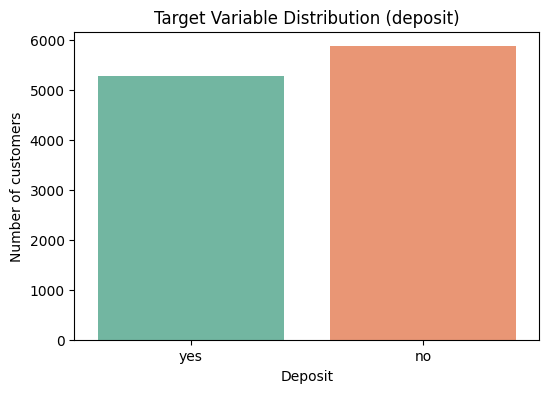

In [ ]:
print(df["deposit"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="deposit", palette="Set2")
plt.title("Target Variable Distribution (deposit)")
plt.xlabel("Deposit")
plt.ylabel("Number of customers")

## Age Distribution

We plot a histogram of the `age` column to understand the dominant age group among bank customers, along with a boxplot next to it to detect any outliers in age.

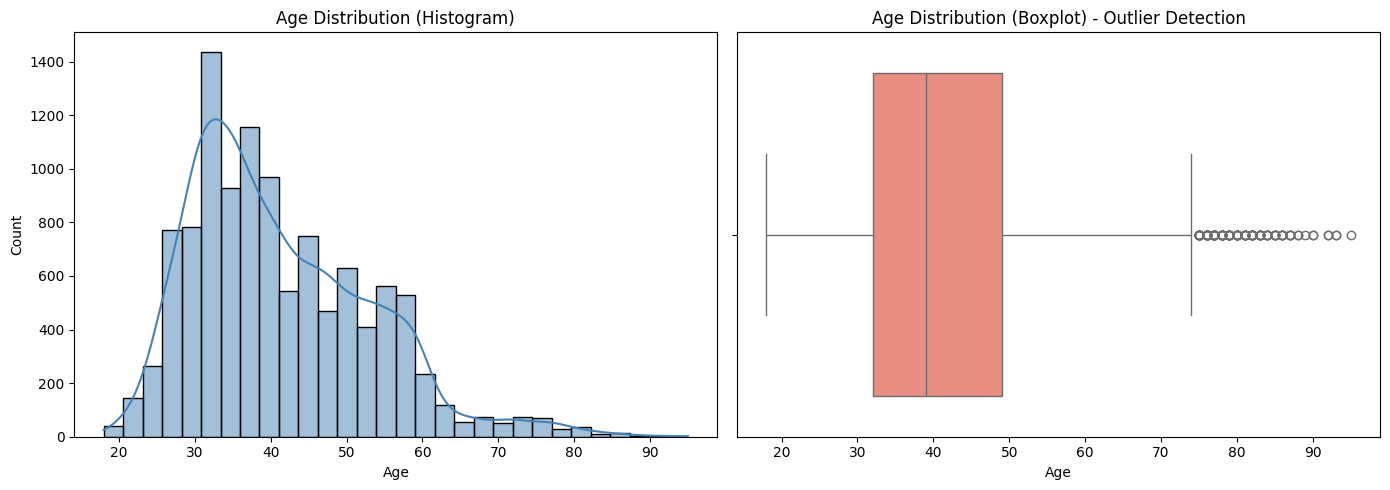

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # wide figure to fit two side-by-side plots

# Histogram
sns.histplot(df["age"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution (Histogram)")
axes[0].set_xlabel("Age")

# boxplot
sns.boxplot(x=df["age"], ax=axes[1], color="salmon")
axes[1].set_title("Age Distribution (Boxplot) - Outlier Detection")
axes[1].set_xlabel("Age")

plt.tight_layout()
plt.show()

#Distribution of Key Categorical Columns

We create a count plot for each of the main categorical columns: `job`, `marital`, `education`, `default`, `housing`, `loan`, `contact`, `poutcome`. This lets us visually see the most common categories in each column.

/tmp/ipykernel_10777/1250477833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10777/1250477833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10777/1250477833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10777/1250477833.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecate

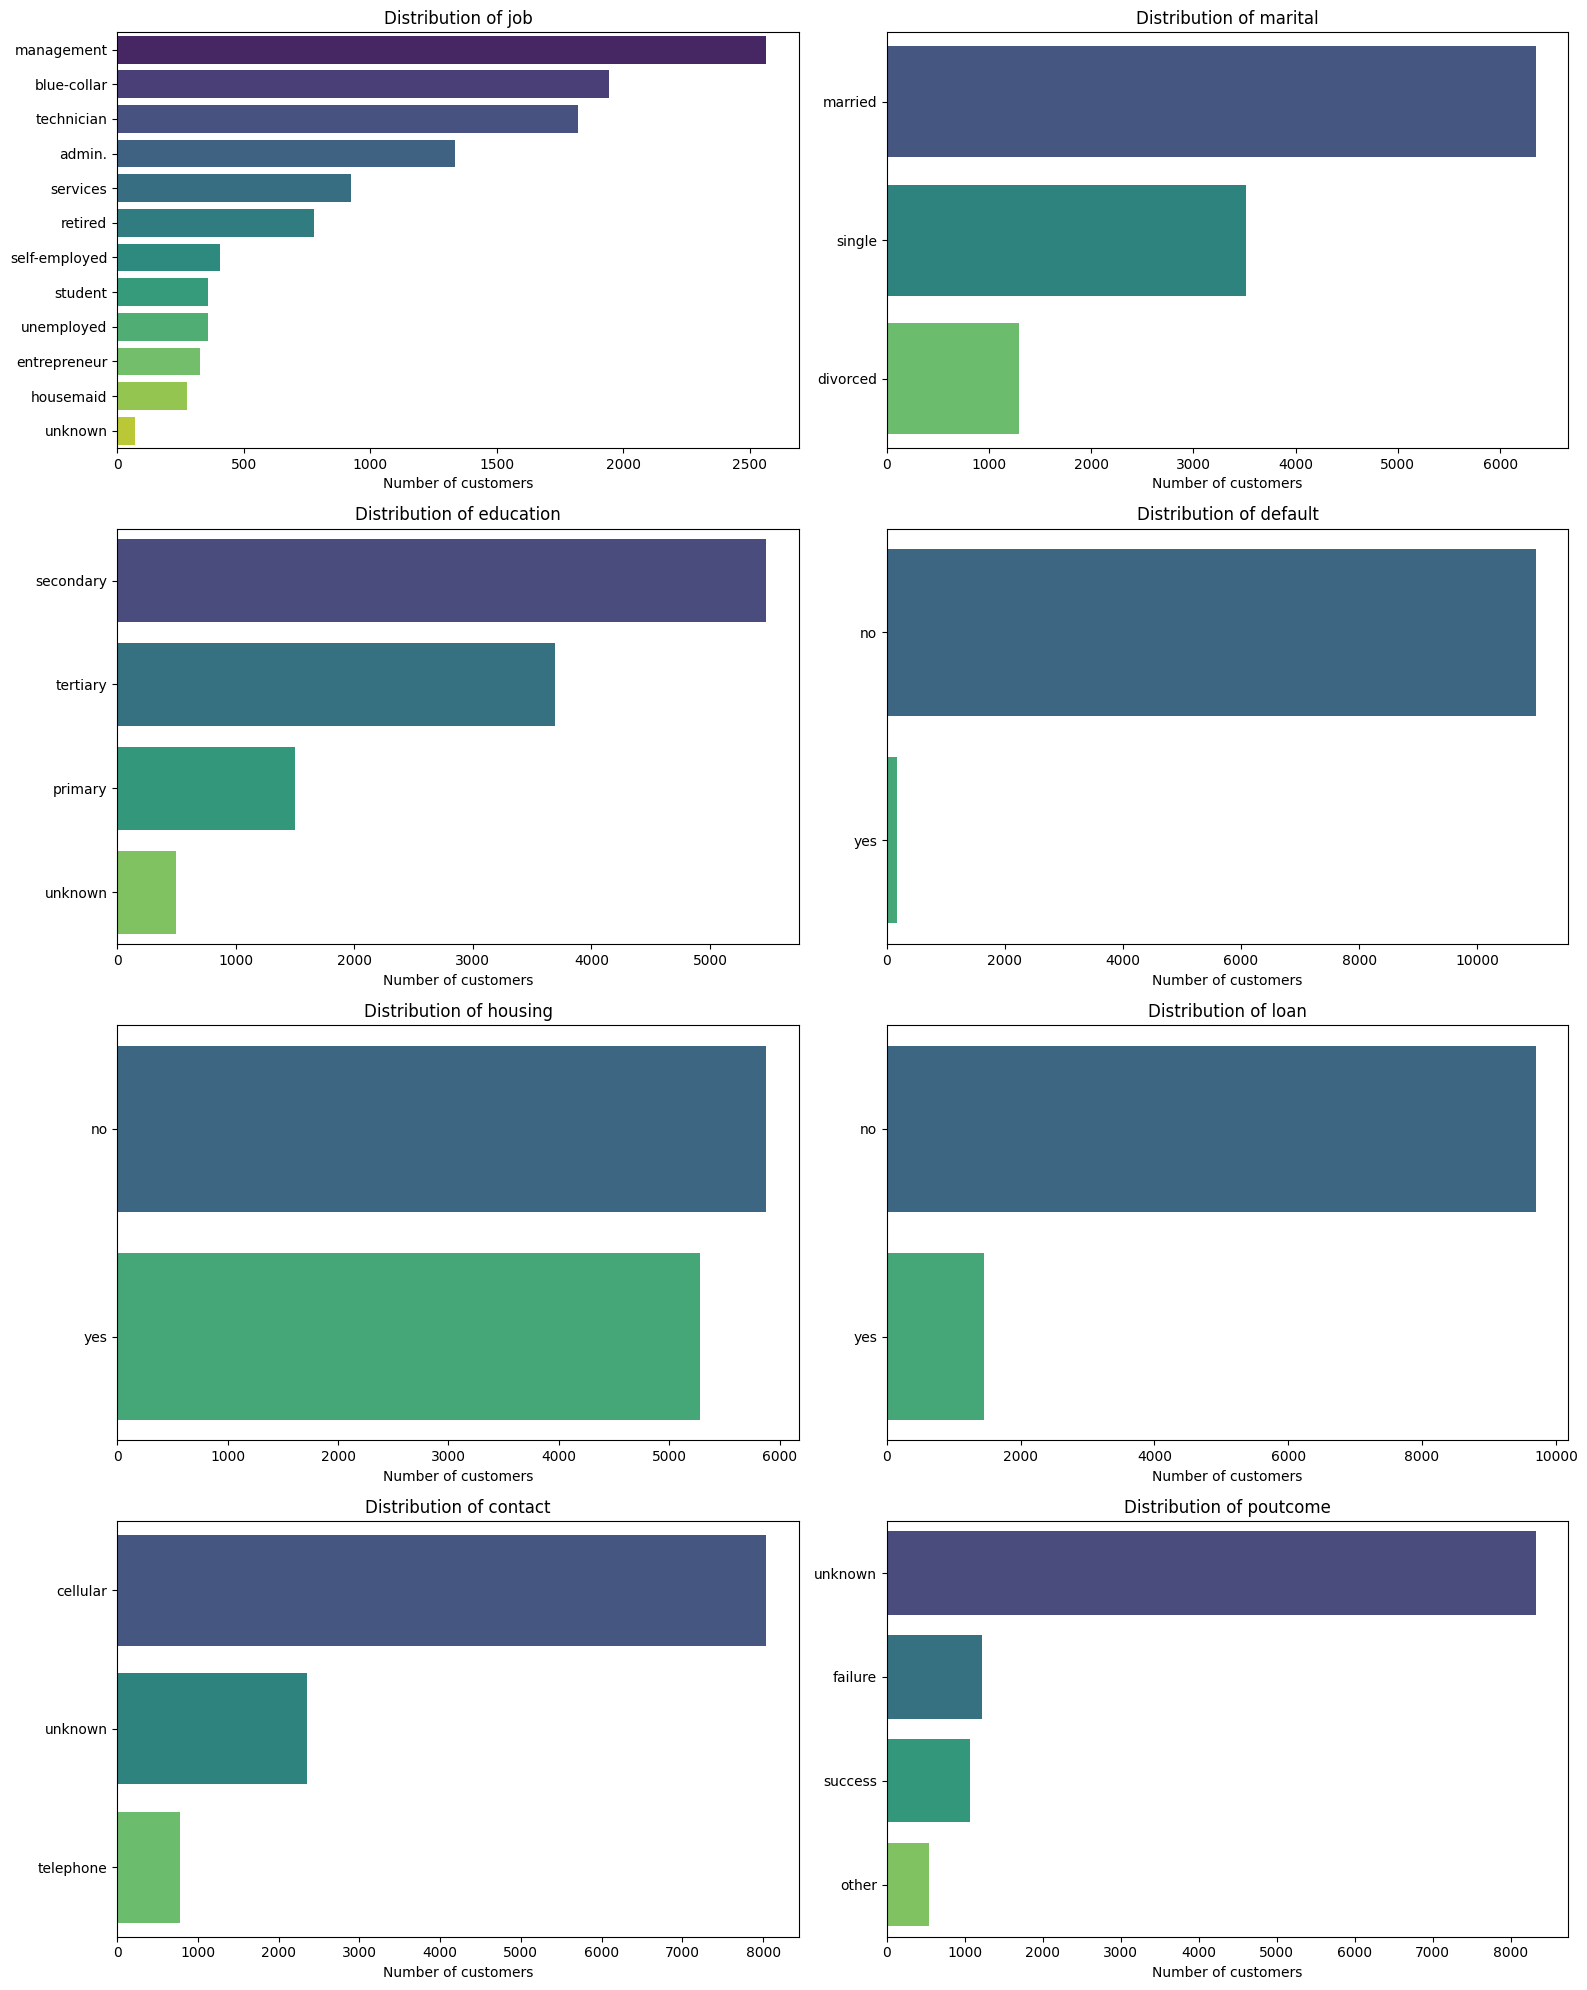

In [ ]:
categorical_features = ["job", "marital", "education", "default",
                        "housing", "loan", "contact", "poutcome"]
fig, axes = plt.subplots(4, 2, figsize=(16, 20))  # large grid figure since it holds 8 subplots
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel("Number of customers")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

##Job Type vs. Term Deposit Subscription

We look at the subscription rate (`deposit = yes`) for each job category, to understand which job types respond best to the marketing campaign.

deposit               no        yes
job                                
student        25.277778  74.722222
retired        33.676093  66.323907
unemployed     43.417367  56.582633
management     49.298519  50.701481
unknown        51.428571  48.571429
admin.         52.698651  47.301349
self-employed  53.827160  46.172840
technician     53.922106  46.077894
services       60.021668  39.978332
housemaid      60.218978  39.781022
entrepreneur   62.500000  37.500000
blue-collar    63.580247  36.419753


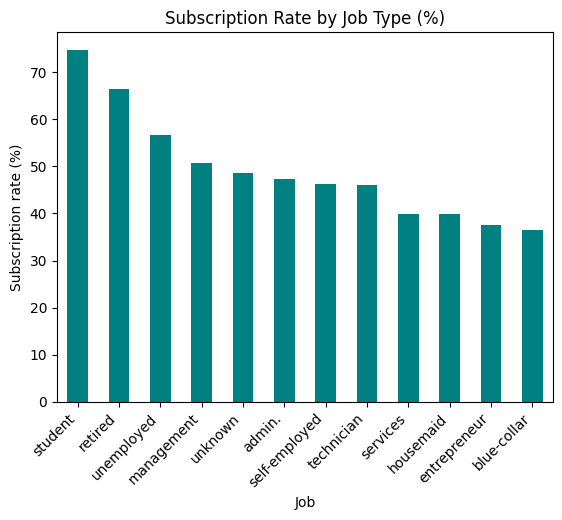

In [ ]:
# Cross-tab: percentage of yes/no deposit for each job type (normalize="index" computes % within each row)
job_deposit = pd.crosstab(df["job"], df["deposit"], normalize="index") * 100

# Sort jobs descending by subscription rate (yes) so the highest rate appears first
job_deposit = job_deposit.sort_values(by="yes", ascending=False)
print(job_deposit)

# Vertical bar chart showing the subscription rate (yes) for each job
job_deposit["yes"].plot(kind="bar", color="teal")

plt.title("Subscription Rate by Job Type (%)")
plt.xlabel("Job")
plt.ylabel("Subscription rate (%)")
plt.xticks(rotation=45, ha="right")  # rotate job names so they don't overlap
plt.show()

## Marital Status and Education vs. Target

Same idea as the previous step, but applied to `marital` and `education`, to see whether marital status or education level affect the subscription decision.

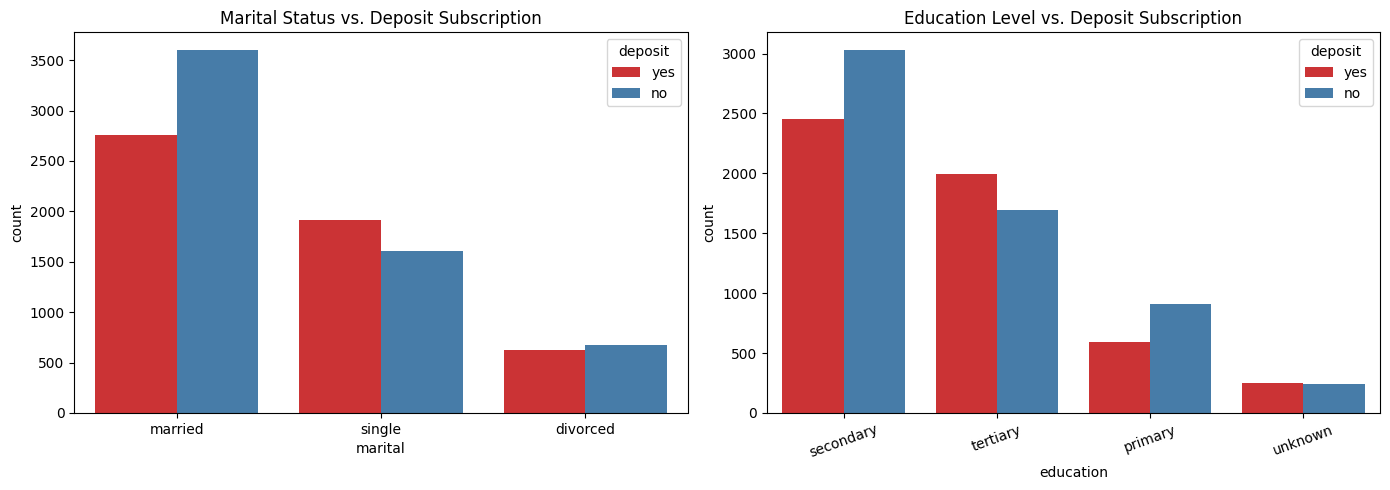

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(data=df, x="marital", hue="deposit", ax=axes[0], palette="Set1")
axes[0].set_title("Marital Status vs. Deposit Subscription")

sns.countplot(data=df, x="education", hue="deposit", ax=axes[1], palette="Set1")
axes[1].set_title("Education Level vs. Deposit Subscription")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Balance Distribution and Outliers

The `balance` column (average yearly balance in euros) often contains large outliers (customers with very high balances) as well as negative values (customers in debt). We plot a boxplot and compute the IQR bounds to identify outliers numerically.

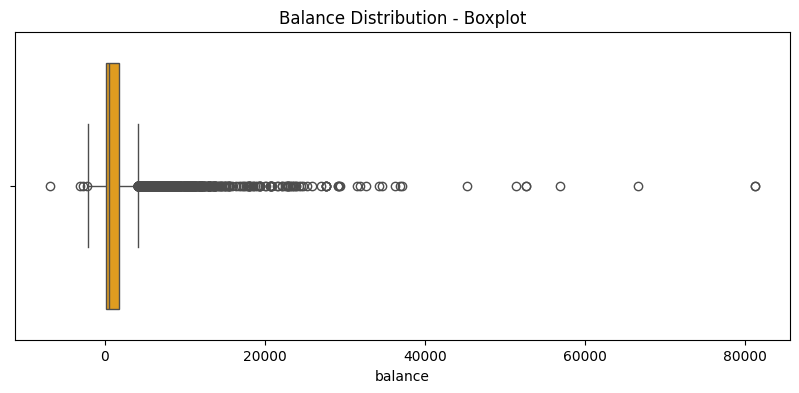

Lower bound: -2257.00
Upper bound: 4087.00
Number of outliers in balance: 1055 (9.45%)


In [ ]:
plt.figure(figsize=(10, 4))  # wide and short, suited to a single horizontal boxplot
sns.boxplot(x=df["balance"], color="orange")
plt.title("Balance Distribution - Boxplot")
plt.show()

# Compute outlier bounds using the IQR method
Q1 = df["balance"].quantile(0.25)
Q3 = df["balance"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["balance"] < lower_bound) | (df["balance"] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of outliers in balance: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")



### Balance Distribution Analysis

In this section, we perform two key steps to understand the behavior and distribution of the `balance` variable:

1. **Descriptive Statistics (`describe`)**: Summarizes the key numerical metrics, including the mean, standard deviation, min/max values, and quartiles.
2. **Distribution Plot (`Histogram`)**: Visualizes the overall shape of the data to identify potential skewness, concentration of values, or outliers.



count    11162.000000
mean      1528.538524
std       3225.413326
min      -6847.000000
25%        122.000000
50%        550.000000
75%       1708.000000
max      81204.000000
Name: balance, dtype: float64


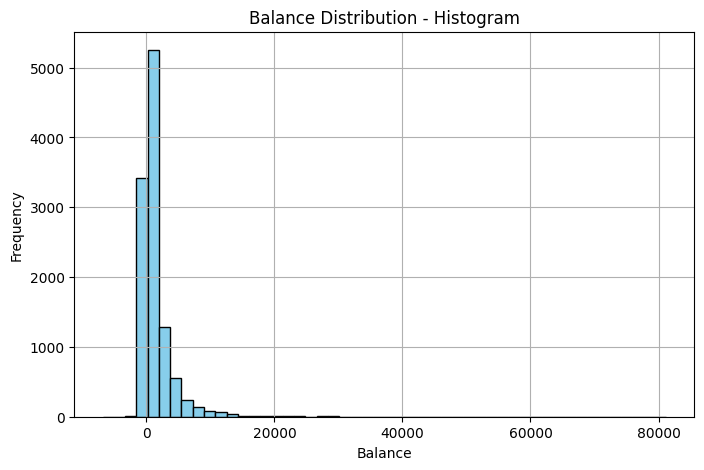

In [ ]:
# Descriptive statistics for the balance column
print(df["balance"].describe())

# Histogram to visualize the distribution
plt.figure(figsize=(8, 5))
df["balance"].hist(bins=50, color="skyblue", edgecolor="black")
plt.title("Balance Distribution - Histogram")
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.show()

##   Correlation Matrix Between Numerical Columns

We use a heatmap to visualize the linear relationships between numerical columns such as `age`, `balance`, `day`, `duration`, `campaign`, `pdays`, `previous`. This helps us spot any strong correlations (multicollinearity).

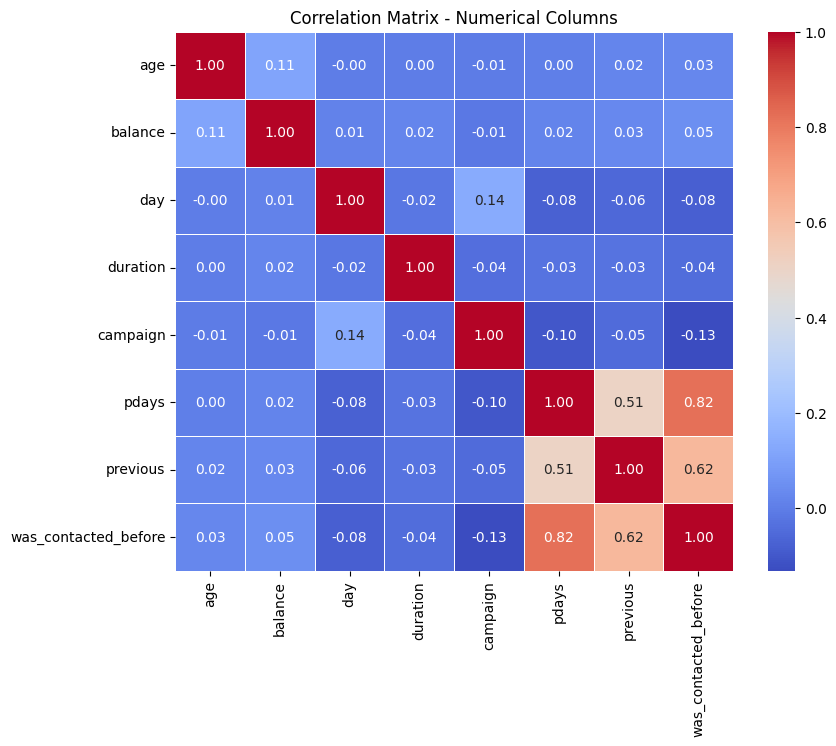

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))  # roughly square, fits a 7x7 correlation matrix comfortably
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix - Numerical Columns")
plt.show()

## Previous Campaign Outcome (`poutcome`) and Its Effect on the Current Decision

We check whether customers for whom a previous campaign was successful (`poutcome = success`) are more likely to subscribe again in the current campaign.

deposit          no        yes
poutcome                      
failure   49.674267  50.325733
other     42.830540  57.169460
success    8.683473  91.316527
unknown   59.332212  40.667788


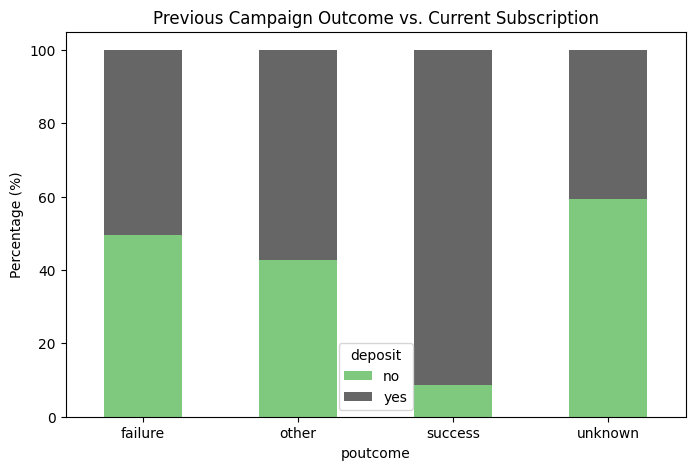

In [ ]:
poutcome_deposit = pd.crosstab(df["poutcome"], df["deposit"], normalize="index") * 100
print(poutcome_deposit)

poutcome_deposit.plot(kind="bar", stacked=True, colormap="Accent", figsize=(8, 5))  # figsize passed directly to the plot call
plt.title("Previous Campaign Outcome vs. Current Subscription")
plt.xlabel("poutcome")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="deposit")
plt.show()

##   Age vs. Balance, Colored by Target

A simple scatter plot between `age` and `balance`, colored by `deposit`, to see if there's a visible pattern relating age/balance to the subscription decision.

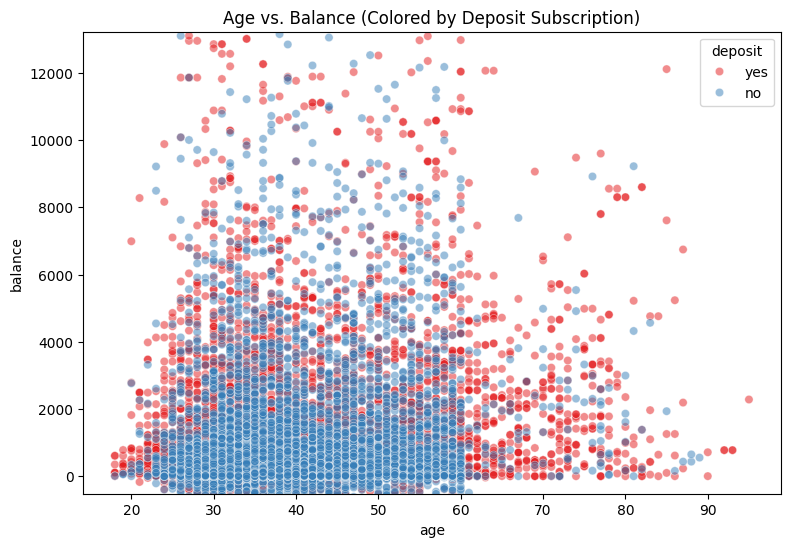

In [ ]:
plt.figure(figsize=(9, 6))  # medium-sized scatter plot with room for the legend
sns.scatterplot(data=df, x="age", y="balance", hue="deposit", alpha=0.5, palette="Set1")
plt.title("Age vs. Balance (Colored by Deposit Subscription)")
plt.ylim(df["balance"].quantile(0.01), df["balance"].quantile(0.99))  # ignore extreme outliers just for plotting
plt.show()



# Handling Outliers in the Campaign Feature
 The `campaign` feature contains some extreme values that may affect the analysis and machine learning model. To reduce the influence of these outliers without removing any observations, values above the 99th percentile are capped at the 99th percentile value.



In [ ]:
# Identify the 99th percentile value of the 'campaign' column as the upper limit.
# Any values higher than this limit are considered extreme outliers.
# Instead of deleting these outliers, replace them with the 99th percentile value.
# This helps reduce the effect of extreme values while keeping all observations in the dataset.
cap = df["campaign"].quantile(0.99)
df["campaign"] = df["campaign"].clip(upper=cap)

# Encoding
Encode binary categorical columns (yes/no -> 1/0)


In [ ]:
binary_cols = ["default", "housing", "loan", "deposit"]
for col in binary_cols:
    df[col] = df[col].map({"yes": 1, "no": 0})



# One-hot encode nominal categorical columns
  
drop_first=True avoids the dummy variable trap (multicollinearity)

In [ ]:
nominal_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)


## Scale numeric columns using StandardScaler
Fit only on the features (X), never on the target (y),
so the target stays as clean 0/1 labels.

In [ ]:
# Scale numeric columns (fit only on features, not target)

numeric_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]

X = df_encoded.drop(columns=["deposit"])
y = df_encoded["deposit"]

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print(X.shape)
X.head()

(11162, 43)


,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,was_contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,1.491505,0,0.252525,1,0,-1.265746,1042,-0.658755,-0.48043,-0.36326,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
1,1.239676,0,-0.459974,0,0,-1.265746,1467,-0.658755,-0.48043,-0.36326,0,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,-0.019470,0,-0.080160,1,0,-1.265746,1389,-0.658755,-0.48043,-0.36326,0,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
3,1.155733,0,0.293762,1,0,-1.265746,579,-0.658755,-0.48043,-0.36326,0,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
4,1.071790,0,-0.416876,0,0,-1.265746,673,-0.199335,-0.48043,-0.36326,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True


# Encoding & Logistic Regression

## Prepare Data and Define X & y
We create a separate copy of the cleaned dataset for the Logistic Regression workflow.
Note: the 'deposit' column (along with default/housing/loan) was already encoded from
yes/no to 1/0 inside Fatma's EDA notebook, so no re-mapping is needed here.
We separate the features (X) from the target (y).

In [ ]:
# Create a separate copy for the Logistic Regression workflow
LR_df = df.copy()

# deposit was already encoded to 0/1 by Fatma in the EDA step - verify here
print("deposit current values:", LR_df["deposit"].unique())

# Define target and features
LR_y = LR_df["deposit"]
LR_X = LR_df.drop(columns=["deposit"])

print("LR_X shape:", LR_X.shape)
print("LR_y shape:", LR_y.shape)

print("\nTarget distribution:")
print(LR_y.value_counts())

print("\nTarget distribution (%):")
print((LR_y.value_counts(normalize=True) * 100).round(2))

deposit current values: [1 0]
LR_X shape: (11162, 17)
LR_y shape: (11162,)

Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64

Target distribution (%):
deposit
0    52.62
1    47.38
Name: proportion, dtype: float64


##  Identify Numerical & Categorical Features
We list the remaining categorical columns that still need One-Hot Encoding
(binary columns default/housing/loan/was_contacted_before were already encoded
by Fatma) and the numerical columns that will need scaling.

In [ ]:
LR_multi_cat_cols = ["job", "marital", "education", "contact", "month", "poutcome"]
LR_numerical_cols = ["age", "balance", "day", "campaign", "pdays", "previous"]
LR_corr_check_cols = LR_numerical_cols + ["was_contacted_before"]

print("Multi-category columns:", LR_multi_cat_cols)
print("Numerical columns:", LR_numerical_cols)

Multi-category columns: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
Numerical columns: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']


## Step 3 — Check Correlation
We check correlation including was_contacted_before, since the EDA showed a
strong correlation (0.82) between pdays and was_contacted_before. We keep this
in mind for interpreting coefficients later, without dropping any feature yet.

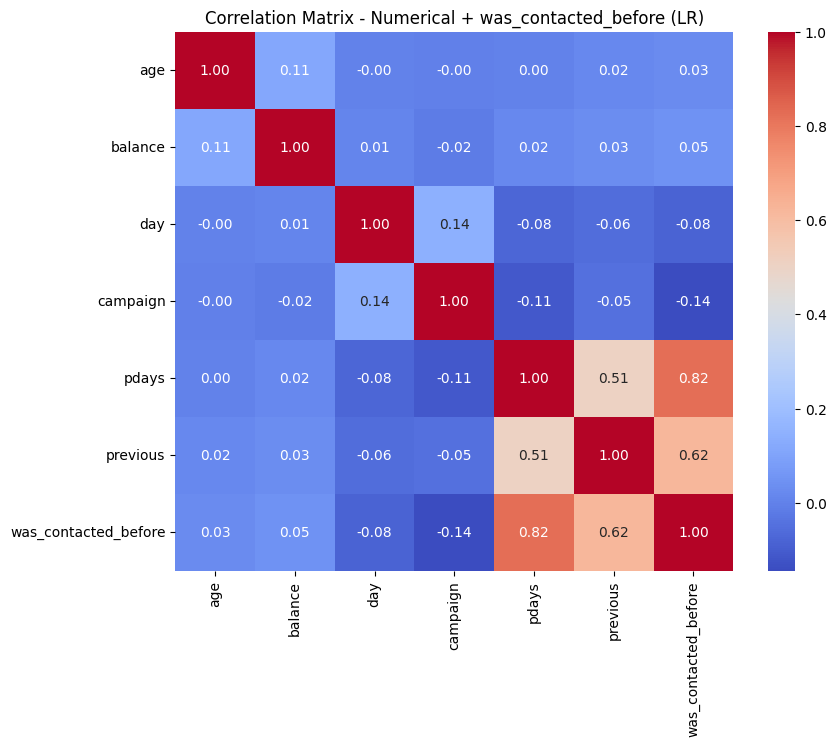

In [ ]:
plt.figure(figsize=(9, 7))
sns.heatmap(LR_X[LR_corr_check_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Numerical + was_contacted_before (LR)")
plt.show()

## Train/Test Split
We split the data into training and test sets before any encoding or scaling,
to avoid data leakage.

In [ ]:
from sklearn.model_selection import train_test_split

LR_X_train, LR_X_test, LR_y_train, LR_y_test = train_test_split(
    LR_X, LR_y, test_size=0.2, random_state=42, stratify=LR_y
)

print("Train shape:", LR_X_train.shape)
print("Test shape:", LR_X_test.shape)

Train shape: (8929, 17)
Test shape: (2233, 17)


## Step 5 — One-Hot Encoding
We use OneHotEncoder instead of pd.get_dummies to properly follow the
fit-on-train / transform-on-test rule. handle_unknown="ignore" also protects
against any category appearing in test but not in train.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

LR_encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

LR_train_encoded = LR_encoder.fit_transform(LR_X_train[LR_multi_cat_cols])
LR_test_encoded = LR_encoder.transform(LR_X_test[LR_multi_cat_cols])

LR_encoded_cols = LR_encoder.get_feature_names_out(LR_multi_cat_cols)

LR_train_encoded_df = pd.DataFrame(LR_train_encoded, columns=LR_encoded_cols, index=LR_X_train.index)
LR_test_encoded_df = pd.DataFrame(LR_test_encoded, columns=LR_encoded_cols, index=LR_X_test.index)

LR_X_train = pd.concat([LR_X_train.drop(columns=LR_multi_cat_cols), LR_train_encoded_df], axis=1)
LR_X_test = pd.concat([LR_X_test.drop(columns=LR_multi_cat_cols), LR_test_encoded_df], axis=1)

print("LR_X_train shape after encoding:", LR_X_train.shape)
print("LR_X_test shape after encoding:", LR_X_test.shape)

LR_X_train shape after encoding: (8929, 43)
LR_X_test shape after encoding: (2233, 43)


## Feature Scaling
We scale the numerical columns using StandardScaler, fitting only on the training
set and applying the same transformation to the test set.

In [ ]:
LR_scaler = StandardScaler()

LR_X_train[LR_numerical_cols] = LR_scaler.fit_transform(LR_X_train[LR_numerical_cols])
LR_X_test[LR_numerical_cols] = LR_scaler.transform(LR_X_test[LR_numerical_cols])

LR_X_train.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,was_contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,education_secondary,education_tertiary,education_unknown,contact_telephone,contact_unknown,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
8644,0.412051,0,-0.321431,0,1,1.817208,251,0.268455,-0.483283,-0.355931,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2632,0.412051,0,0.359538,0,0,-1.504820,260,-0.656327,0.381392,3.075684,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3056,-1.356310,0,-0.451508,0,1,-0.555669,202,-0.656327,0.353796,0.073021,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1080,0.159428,0,0.606919,1,0,0.630770,775,0.268455,-0.483283,-0.355931,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4006,-0.345818,0,-0.425291,0,0,0.868057,272,-0.193936,-0.483283,-0.355931,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## Step 7 — Baseline Logistic Regression
We train a baseline Logistic Regression model with default hyperparameters,
using max_iter=1000 (instead of sklearn's default 100) to ensure convergence.

In [ ]:
from sklearn.linear_model import LogisticRegression

LR_model = LogisticRegression(max_iter=1000, random_state=42)
LR_model.fit(LR_X_train, LR_y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

## Step 8 — Balanced Logistic Regression
We train a second model with class_weight="balanced" to compare against the
baseline, since the target classes are imbalanced.

In [ ]:
LR_model_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
LR_model_balanced.fit(LR_X_train, LR_y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Step 9 — Predictions
We generate predictions and probability scores on the test set for both models.
predict_proba() is kept for later use in Threshold Tuning.

In [ ]:
LR_predictions = LR_model.predict(LR_X_test)
LR_predictions_balanced = LR_model_balanced.predict(LR_X_test)

LR_proba = LR_model.predict_proba(LR_X_test)[:, 1]
LR_proba_balanced = LR_model_balanced.predict_proba(LR_X_test)[:, 1]

## Step 10 — Evaluation
We evaluate both models using Accuracy, Precision, Recall, F1-score, ROC-AUC,
and the Confusion Matrix.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)

def LR_evaluate(y_true, y_pred, y_proba, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print()

LR_evaluate(LR_y_test, LR_predictions, LR_proba, "Logistic Regression (Default)")
LR_evaluate(LR_y_test, LR_predictions_balanced, LR_proba_balanced, "Logistic Regression (Balanced)")

--- Logistic Regression (Default) ---
Accuracy: 0.8266905508284819
Precision: 0.8273170731707317
Recall: 0.8015122873345936
F1-score: 0.814210273643783
ROC-AUC: 0.9069838716164582
Confusion Matrix:
 [[998 177]
 [210 848]]

--- Logistic Regression (Balanced) ---
Accuracy: 0.8284818629646216
Precision: 0.8205128205128205
Recall: 0.8166351606805293
F1-score: 0.8185693983893889
ROC-AUC: 0.9069854804327716
Confusion Matrix:
 [[986 189]
 [194 864]]



## Step 11 — Interpret Coefficients
We inspect the baseline model's coefficients in terms of log-odds, and convert
them to Odds Ratios (exp(coefficient)) for a more intuitive interpretation.
Note: coefficient magnitude alone can be misleading with one-hot encoded
features, and pdays/previous/was_contacted_before are correlated, so their
individual coefficients should be interpreted with caution.

In [ ]:
LR_coefficients = pd.DataFrame({
    "Feature": LR_X_train.columns,
    "Coefficient": LR_model.coef_[0]
})
LR_coefficients["Odds_Ratio"] = np.exp(LR_coefficients["Coefficient"])
LR_coefficients = LR_coefficients.sort_values(by="Coefficient", ascending=False)

print("Top positive features:")
print(LR_coefficients.head(10))

print("\nTop negative features:")
print(LR_coefficients.tail(10))

Top positive features:
               Feature  Coefficient  Odds_Ratio
41    poutcome_success     2.184695    8.887936
35           month_mar     1.753335    5.773827
30           month_dec     1.209619    3.352207
38           month_oct     0.869878    2.386621
39           month_sep     0.748163    2.113114
18         job_student     0.692376    1.998458
25  education_tertiary     0.549647    1.732641
26   education_unknown     0.336635    1.400228
15         job_retired     0.261984    1.299506
34           month_jun     0.228748    1.257026

Top negative features:
              Feature  Coefficient  Odds_Ratio
4                loan    -0.553629    0.574860
16  job_self-employed    -0.560182    0.571105
21        job_unknown    -0.629411    0.532906
3             housing    -0.682687    0.505258
36          month_may    -0.720658    0.486432
29          month_aug    -0.852767    0.426234
37          month_nov    -1.009187    0.364515
33          month_jul    -1.037109    0.354478
32

## Step 12 — Threshold Tuning
We test a different classification threshold instead of the default 0.5,
to see the effect on Recall/Precision trade-off, since Recall may matter more
than Accuracy for identifying potential subscribers.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

LR_threshold = 0.3  # example: lowering the threshold to catch more positives
LR_predictions_thresh = (LR_proba_balanced >= LR_threshold).astype(int)

print(f"--- Threshold = {LR_threshold} ---")
print("Precision:", precision_score(LR_y_test, LR_predictions_thresh))
print("Recall:", recall_score(LR_y_test, LR_predictions_thresh))
print("F1-score:", f1_score(LR_y_test, LR_predictions_thresh))

--- Threshold = 0.3 ---
Precision: 0.7424698795180723
Recall: 0.9319470699432892
F1-score: 0.826487845766974


## Step 13 — Final Comparison & Report
We compare both models across all evaluation metrics. There is no single
"best" model across every metric - the choice depends on the project's main
objective (e.g., if the goal is capturing as many potential subscribers as
possible, Recall is the priority metric).

In [ ]:
LR_results = pd.DataFrame({
    "Model": ["Default", "Balanced"],
    "Accuracy": [accuracy_score(LR_y_test, LR_predictions), accuracy_score(LR_y_test, LR_predictions_balanced)],
    "Precision": [precision_score(LR_y_test, LR_predictions), precision_score(LR_y_test, LR_predictions_balanced)],
    "Recall": [recall_score(LR_y_test, LR_predictions), recall_score(LR_y_test, LR_predictions_balanced)],
    "F1-score": [f1_score(LR_y_test, LR_predictions), f1_score(LR_y_test, LR_predictions_balanced)],
    "ROC-AUC": [roc_auc_score(LR_y_test, LR_proba), roc_auc_score(LR_y_test, LR_proba_balanced)]
})

print(LR_results)

      Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0   Default  0.826691   0.827317  0.801512  0.814210  0.906984
1  Balanced  0.828482   0.820513  0.816635  0.818569  0.906985


KNN

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression.

The algorithm makes predictions based on the closest training samples to a new data point.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

## Create the KNN Model

We create a KNN classifier with K = 5 as a baseline.

In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors=5)

# **## KNN Baseline Model**

We will first build a baseline K-Nearest Neighbors (KNN) classifier using the preprocessed training data.

The baseline model will provide a reference performance before performing hyperparameter tuning and optimization.

In [ ]:
KNN_X_train = LR_X_train.copy()
KNN_X_test = LR_X_test.copy()
KNN_y_train = LR_y_train.copy()
KNN_y_test = LR_y_test.copy()

## Model Training

The KNN model is trained using the training data.

In [ ]:
KNN_model.fit(KNN_X_train, KNN_y_train)

KNeighborsClassifier()

## Prediction

The trained KNN model is used to predict the classes of the test data.

In [ ]:
KNN_y_pred = KNN_model.predict(KNN_X_test)

## Baseline Evaluation

We evaluate the KNN model using accuracy as the first performance metric.

In [ ]:
KNN_accuracy = accuracy_score(KNN_y_test, KNN_y_pred)

print("KNN Accuracy:", KNN_accuracy)

KNN Accuracy: 0.7671294223018361


## Precision

Precision measures how many of the samples predicted as positive are actually positive.

In [ ]:
KNN_precision = precision_score(KNN_y_test, KNN_y_pred)

print("KNN Precision:", KNN_precision)

KNN Precision: 0.7576628352490421


## Recall

Recall measures how many of the actual positive samples were correctly identified by the model.

In [ ]:
KNN_recall = recall_score(KNN_y_test, KNN_y_pred)

print("KNN Recall:", KNN_recall)

KNN Recall: 0.7476370510396976


## F1 Score

F1-score combines Precision and Recall into a single metric.

In [ ]:
KNN_f1 = f1_score(KNN_y_test, KNN_y_pred)

print("KNN F1 Score:", KNN_f1)

KNN F1 Score: 0.7526165556612749


## Confusion Matrix

The confusion matrix shows the correct and incorrect predictions for each class.

In [ ]:
KNN_cm = confusion_matrix(KNN_y_test, KNN_y_pred)

print(KNN_cm)

[[922 253]
 [267 791]]


## Classification Report

The classification report summarizes the main evaluation metrics for each class.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(KNN_y_test, KNN_y_pred))

              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1175
           1       0.76      0.75      0.75      1058

    accuracy                           0.77      2233
   macro avg       0.77      0.77      0.77      2233
weighted avg       0.77      0.77      0.77      2233



## Selecting the Best K

We test different values of K to find the value that gives the best validation performance.

In [ ]:
from sklearn.model_selection import cross_val_score
KNN_k_values = range(1, 30)
KNN_cv_scores = []

for k in KNN_k_values:
    KNN_cv_model = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        KNN_cv_model,
        KNN_X_train,
        KNN_y_train,
        cv=5,
        scoring="accuracy"
    )

    KNN_cv_scores.append(scores.mean())

KNN_best_index = np.argmax(KNN_cv_scores)
KNN_best_k = list(KNN_k_values)[KNN_best_index]
KNN_best_cv_score = KNN_cv_scores[KNN_best_index]

print("Best K:", KNN_best_k)
print("Best CV Accuracy:", KNN_best_cv_score)

print("\nK Values and CV Accuracy:")
for k, score in zip(KNN_k_values, KNN_cv_scores):
    print(f"K = {k:2d} --> Accuracy = {score:.4f}")

Best K: 17
Best CV Accuracy: 0.7689544261153509

K Values and CV Accuracy:
K =  1 --> Accuracy = 0.7224
K =  2 --> Accuracy = 0.6971
K =  3 --> Accuracy = 0.7541
K =  4 --> Accuracy = 0.7365
K =  5 --> Accuracy = 0.7629
K =  6 --> Accuracy = 0.7479
K =  7 --> Accuracy = 0.7641
K =  8 --> Accuracy = 0.7516
K =  9 --> Accuracy = 0.7643
K = 10 --> Accuracy = 0.7550
K = 11 --> Accuracy = 0.7688
K = 12 --> Accuracy = 0.7607
K = 13 --> Accuracy = 0.7678
K = 14 --> Accuracy = 0.7612
K = 15 --> Accuracy = 0.7681
K = 16 --> Accuracy = 0.7621
K = 17 --> Accuracy = 0.7690
K = 18 --> Accuracy = 0.7638
K = 19 --> Accuracy = 0.7657
K = 20 --> Accuracy = 0.7609
K = 21 --> Accuracy = 0.7646
K = 22 --> Accuracy = 0.7600
K = 23 --> Accuracy = 0.7636
K = 24 --> Accuracy = 0.7576
K = 25 --> Accuracy = 0.7591
K = 26 --> Accuracy = 0.7539
K = 27 --> Accuracy = 0.7576
K = 28 --> Accuracy = 0.7539
K = 29 --> Accuracy = 0.7560


## Final KNN Model

We train the final KNN model using the best K value selected through cross-validation.

In [ ]:
KNN_best_k = KNN_best_index

KNN_best_model = KNeighborsClassifier(n_neighbors=KNN_best_k)

KNN_best_model.fit(KNN_X_train, KNN_y_train)

KNeighborsClassifier(n_neighbors=np.int64(16))

## Final Model Prediction

We use the final KNN model to predict the classes of the test data.

In [ ]:
KNN_best_y_pred = KNN_best_model.predict(KNN_X_test)

## KNN Distance Metrics

We evaluate different distance metrics while keeping the best K fixed.

In [ ]:
KNN_metrics = ["euclidean", "manhattan", "minkowski", "chebyshev"]

KNN_metric_results = {}

for metric in KNN_metrics:
    KNN_metric_model = KNeighborsClassifier(
        n_neighbors=KNN_best_k,
        metric=metric
    )

    KNN_metric_model.fit(KNN_X_train, KNN_y_train)

    KNN_metric_pred = KNN_metric_model.predict(KNN_X_test)

    KNN_metric_results[metric] = {
        "KNN_metric_Accuracy": accuracy_score(KNN_y_test, KNN_metric_pred),
        "KNN_metric_Precision": precision_score(KNN_y_test, KNN_metric_pred),
        "KNN_metric_Recall": recall_score(KNN_y_test, KNN_metric_pred),
        "KNN_metric_F1": f1_score(KNN_y_test, KNN_metric_pred)
    }

for metric, results in KNN_metric_results.items():
    print(f"\nMetric: {metric}")
    print(f"Accuracy : {results['KNN_metric_Accuracy']:.4f}")
    print(f"Precision: {results['KNN_metric_Precision']:.4f}")
    print(f"Recall   : {results['KNN_metric_Recall']:.4f}")
    print(f"F1       : {results['KNN_metric_F1']:.4f}")


Metric: euclidean
Accuracy : 0.7586
Precision: 0.7740
Recall   : 0.6928
F1       : 0.7312

Metric: manhattan
Accuracy : 0.7819
Precision: 0.7910
Recall   : 0.7335
F1       : 0.7612

Metric: minkowski
Accuracy : 0.7586
Precision: 0.7740
Recall   : 0.6928
F1       : 0.7312

Metric: chebyshev
Accuracy : 0.7255
Precision: 0.7335
Recall   : 0.6607
F1       : 0.6952


## KNN Weighting Methods

We evaluate uniform and distance-based weighting using the best K and distance metric.

In [ ]:
KNN_weights = ["uniform", "distance"]

KNN_weight_results = {}

for weight in KNN_weights:
    KNN_weight_model = KNeighborsClassifier(
        n_neighbors=KNN_best_k,
        metric="manhattan",
        weights=weight
    )

    KNN_weight_model.fit(KNN_X_train, KNN_y_train)

    KNN_weight_pred = KNN_weight_model.predict(KNN_X_test)

    KNN_weight_results[weight] = {
        "KNN_weight_Accuracy": accuracy_score(KNN_y_test, KNN_weight_pred),
        "KNN_weight_Precision": precision_score(KNN_y_test, KNN_weight_pred),
        "KNN_weight_Recall": recall_score(KNN_y_test, KNN_weight_pred),
        "KNN_weight_F1": f1_score(KNN_y_test, KNN_weight_pred)
    }

for weight, results in KNN_weight_results.items():
    print(f"\nWeight: {weight}")
    print(f"Accuracy : {results['KNN_weight_Accuracy']:.4f}")
    print(f"Precision: {results['KNN_weight_Precision']:.4f}")
    print(f"Recall   : {results['KNN_weight_Recall']:.4f}")
    print(f"F1       : {results['KNN_weight_F1']:.4f}")


Weight: uniform
Accuracy : 0.7819
Precision: 0.7910
Recall   : 0.7335
F1       : 0.7612

Weight: distance
Accuracy : 0.7936
Precision: 0.7890
Recall   : 0.7703
F1       : 0.7795


## KNN Hyperparameter Tuning

We keep the best K value fixed and search for the best combination of distance metric and weighting method.

In [ ]:
from sklearn.model_selection import GridSearchCV
KNN_param_grid = {
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski", "chebyshev"]
}

KNN_grid = GridSearchCV(
    KNeighborsClassifier(n_neighbors=KNN_best_k),
    KNN_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

KNN_grid.fit(KNN_X_train, KNN_y_train)

print("Best Parameters:", KNN_grid.best_params_)
print("Best CV Accuracy:", KNN_grid.best_score_)

Best Parameters: {'metric': 'manhattan', 'weights': 'distance'}
Best CV Accuracy: 0.7891130203481168


## Final KNN Model Evaluation

We evaluate the final KNN model on the test set using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

In [ ]:
# Final KNN model
KNN_grid_best_model = KNN_grid.best_estimator_

# Predictions
KNN_grid_best_pred = KNN_grid_best_model.predict(KNN_X_test)

# Evaluation metrics
KNN_grid_accuracy = accuracy_score(KNN_y_test, KNN_grid_best_pred)
KNN_grid_precision = precision_score(KNN_y_test, KNN_grid_best_pred)
KNN_grid_recall = recall_score(KNN_y_test, KNN_grid_best_pred)
KNN_grid_f1 = f1_score(KNN_y_test, KNN_grid_best_pred)

# Confusion Matrix
KNN_grid_cm = confusion_matrix(KNN_y_test, KNN_grid_best_pred)

# Classification Report
KNN_grid_report = classification_report(KNN_y_test, KNN_grid_best_pred)

# Print results
print("Best Parameters:", KNN_grid.best_params_)
print("CV Accuracy:", KNN_grid.best_score_)

print("\nFinal KNN Test Results:")
print("Accuracy :", KNN_grid_accuracy)
print("Precision:", KNN_grid_precision)
print("Recall   :", KNN_grid_recall)
print("F1 Score :", KNN_grid_f1)

print("\nConfusion Matrix:")
print(KNN_grid_cm)

print("\nClassification Report:")
print(KNN_grid_report)

Best Parameters: {'metric': 'manhattan', 'weights': 'distance'}
CV Accuracy: 0.7891130203481168

Final KNN Test Results:
Accuracy : 0.793551276309897
Precision: 0.7889641819941917
Recall   : 0.7703213610586012
F1 Score : 0.779531324725012

Confusion Matrix:
[[957 218]
 [243 815]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1175
           1       0.79      0.77      0.78      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.79      0.79      0.79      2233



## Decision Tree

Decision Tree is a supervised learning algorithm that makes predictions by splitting the data into branches based on feature values.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
DT_X_train = LR_X_train.copy()
DT_X_test = LR_X_test.copy()

DT_y_train = LR_y_train.copy()
DT_y_test = LR_y_test.copy()

## Baseline Decision Tree

We train a basic Decision Tree classifier as a baseline model.

In [ ]:
DT_model = DecisionTreeClassifier(
    random_state=42
)

DT_model.fit(DT_X_train, DT_y_train)

DT_y_pred = DT_model.predict(DT_X_test)

## Decision Tree Evaluation

In [ ]:
DT_accuracy = accuracy_score(DT_y_test, DT_y_pred)
DT_precision = precision_score(DT_y_test, DT_y_pred)
DT_recall = recall_score(DT_y_test, DT_y_pred)
DT_f1 = f1_score(DT_y_test, DT_y_pred)

DT_cm = confusion_matrix(DT_y_test, DT_y_pred)

print("Decision Tree Accuracy :", DT_accuracy)
print("Decision Tree Precision:", DT_precision)
print("Decision Tree Recall   :", DT_recall)
print("Decision Tree F1 Score :", DT_f1)

print("\nConfusion Matrix:")
print(DT_cm)

print("\nClassification Report:")
print(classification_report(DT_y_test, DT_y_pred))

Decision Tree Accuracy : 0.7953425884460367
Decision Tree Precision: 0.7859181731684111
Decision Tree Recall   : 0.780718336483932
Decision Tree F1 Score : 0.7833096254148886

Confusion Matrix:
[[950 225]
 [232 826]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1175
           1       0.79      0.78      0.78      1058

    accuracy                           0.80      2233
   macro avg       0.79      0.79      0.79      2233
weighted avg       0.80      0.80      0.80      2233



## Decision Tree Criterion

We compare different criteria used to measure the quality of splits.

In [ ]:
DT_criteria = ["gini", "entropy", "log_loss"]

DT_criterion_results = {}

for criterion in DT_criteria:

    DT_criterion_model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )

    DT_criterion_model.fit(DT_X_train, DT_y_train)

    DT_criterion_pred = DT_criterion_model.predict(DT_X_test)

    DT_criterion_results[criterion] = {
        "DT_criterion_Accuracy": accuracy_score(DT_y_test, DT_criterion_pred),
        "DT_criterion_Precision": precision_score(DT_y_test, DT_criterion_pred),
        "DT_criterion_Recall": recall_score(DT_y_test, DT_criterion_pred),
        "DT_criterion_F1": f1_score(DT_y_test, DT_criterion_pred)
    }

for criterion, results in DT_criterion_results.items():

    print(f"\nCriterion: {criterion}")

    print(
        f"Accuracy : "
        f"{results['DT_criterion_Accuracy']:.4f}"
    )

    print(
        f"Precision: "
        f"{results['DT_criterion_Precision']:.4f}"
    )

    print(
        f"Recall   : "
        f"{results['DT_criterion_Recall']:.4f}"
    )

    print(
        f"F1       : "
        f"{results['DT_criterion_F1']:.4f}"
    )


Criterion: gini
Accuracy : 0.7953
Precision: 0.7859
Recall   : 0.7807
F1       : 0.7833

Criterion: entropy
Accuracy : 0.7980
Precision: 0.7855
Recall   : 0.7892
F1       : 0.7874

Criterion: log_loss
Accuracy : 0.7980
Precision: 0.7855
Recall   : 0.7892
F1       : 0.7874


## Decision Tree Max Depth

We evaluate different maximum depths to control the complexity of the Decision Tree.

In [ ]:
DT_depth_values = range(1, 21)

DT_depth_results = {}

for depth in DT_depth_values:

    DT_depth_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    DT_depth_model.fit(DT_X_train, DT_y_train)

    DT_depth_pred = DT_depth_model.predict(DT_X_test)

    DT_depth_results[depth] = {
        "DT_depth_Accuracy": accuracy_score(DT_y_test, DT_depth_pred),
        "DT_depth_Precision": precision_score(DT_y_test, DT_depth_pred),
        "DT_depth_Recall": recall_score(DT_y_test, DT_depth_pred),
        "DT_depth_F1": f1_score(DT_y_test, DT_depth_pred)
    }

for depth, results in DT_depth_results.items():

    print(f"\nMax Depth: {depth}")
    print(f"Accuracy : {results['DT_depth_Accuracy']:.4f}")
    print(f"Precision: {results['DT_depth_Precision']:.4f}")
    print(f"Recall   : {results['DT_depth_Recall']:.4f}")
    print(f"F1       : {results['DT_depth_F1']:.4f}")


Max Depth: 1
Accuracy : 0.6977
Precision: 0.6413
Recall   : 0.8214
F1       : 0.7203

Max Depth: 2
Accuracy : 0.7152
Precision: 0.6492
Recall   : 0.8677
F1       : 0.7427

Max Depth: 3
Accuracy : 0.7801
Precision: 0.7193
Recall   : 0.8790
F1       : 0.7912

Max Depth: 4
Accuracy : 0.7810
Precision: 0.7271
Recall   : 0.8611
F1       : 0.7884

Max Depth: 5
Accuracy : 0.8030
Precision: 0.7866
Recall   : 0.8015
F1       : 0.7940

Max Depth: 6
Accuracy : 0.8133
Precision: 0.8121
Recall   : 0.7883
F1       : 0.8000

Max Depth: 7
Accuracy : 0.8142
Precision: 0.8065
Recall   : 0.7996
F1       : 0.8030

Max Depth: 8
Accuracy : 0.8195
Precision: 0.7821
Recall   : 0.8582
F1       : 0.8184

Max Depth: 9
Accuracy : 0.8177
Precision: 0.7804
Recall   : 0.8563
F1       : 0.8166

Max Depth: 10
Accuracy : 0.8213
Precision: 0.7883
Recall   : 0.8516
F1       : 0.8187

Max Depth: 11
Accuracy : 0.8213
Precision: 0.8009
Recall   : 0.8289
F1       : 0.8147

Max Depth: 12
Accuracy : 0.8262
Precision: 0.8172
R

## Decision Tree Min Samples Split

We evaluate different minimum numbers of samples required to split an internal node.

In [ ]:
DT_split_values = [2, 5, 10, 20, 50, 100]

DT_split_results = {}

for split in DT_split_values:

    DT_split_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=split,
        random_state=42
    )

    DT_split_model.fit(DT_X_train, DT_y_train)

    DT_split_pred = DT_split_model.predict(DT_X_test)

    DT_split_results[split] = {
        "DT_split_Accuracy": accuracy_score(DT_y_test, DT_split_pred),
        "DT_split_Precision": precision_score(DT_y_test, DT_split_pred),
        "DT_split_Recall": recall_score(DT_y_test, DT_split_pred),
        "DT_split_F1": f1_score(DT_y_test, DT_split_pred)
    }

for split, results in DT_split_results.items():

    print(f"\nMin Samples Split: {split}")
    print(f"Accuracy : {results['DT_split_Accuracy']:.4f}")
    print(f"Precision: {results['DT_split_Precision']:.4f}")
    print(f"Recall   : {results['DT_split_Recall']:.4f}")
    print(f"F1       : {results['DT_split_F1']:.4f}")


Min Samples Split: 2
Accuracy : 0.8213
Precision: 0.7883
Recall   : 0.8516
F1       : 0.8187

Min Samples Split: 5
Accuracy : 0.8195
Precision: 0.7860
Recall   : 0.8507
F1       : 0.8171

Min Samples Split: 10
Accuracy : 0.8177
Precision: 0.7848
Recall   : 0.8478
F1       : 0.8151

Min Samples Split: 20
Accuracy : 0.8186
Precision: 0.7842
Recall   : 0.8516
F1       : 0.8165

Min Samples Split: 50
Accuracy : 0.8258
Precision: 0.7906
Recall   : 0.8601
F1       : 0.8239

Min Samples Split: 100
Accuracy : 0.8227
Precision: 0.7791
Recall   : 0.8733
F1       : 0.8235


## Decision Tree Min Samples Leaf

We evaluate different minimum numbers of samples required in a leaf node.

In [ ]:
DT_leaf_values = [1, 2, 5, 10, 20, 50, 100]

DT_leaf_results = {}

for leaf in DT_leaf_values:

    DT_leaf_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=leaf,
        random_state=42
    )

    DT_leaf_model.fit(DT_X_train, DT_y_train)

    DT_leaf_pred = DT_leaf_model.predict(DT_X_test)

    DT_leaf_results[leaf] = {
        "DT_leaf_Accuracy": accuracy_score(DT_y_test, DT_leaf_pred),
        "DT_leaf_Precision": precision_score(DT_y_test, DT_leaf_pred),
        "DT_leaf_Recall": recall_score(DT_y_test, DT_leaf_pred),
        "DT_leaf_F1": f1_score(DT_y_test, DT_leaf_pred)
    }

for leaf, results in DT_leaf_results.items():

    print(f"\nMin Samples Leaf: {leaf}")
    print(f"Accuracy : {results['DT_leaf_Accuracy']:.4f}")
    print(f"Precision: {results['DT_leaf_Precision']:.4f}")
    print(f"Recall   : {results['DT_leaf_Recall']:.4f}")
    print(f"F1       : {results['DT_leaf_F1']:.4f}")


Min Samples Leaf: 1
Accuracy : 0.8227
Precision: 0.7791
Recall   : 0.8733
F1       : 0.8235

Min Samples Leaf: 2
Accuracy : 0.8231
Precision: 0.7793
Recall   : 0.8743
F1       : 0.8241

Min Samples Leaf: 5
Accuracy : 0.8240
Precision: 0.7773
Recall   : 0.8809
F1       : 0.8259

Min Samples Leaf: 10
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

Min Samples Leaf: 20
Accuracy : 0.8155
Precision: 0.7683
Recall   : 0.8743
F1       : 0.8179

Min Samples Leaf: 50
Accuracy : 0.8133
Precision: 0.7642
Recall   : 0.8762
F1       : 0.8164

Min Samples Leaf: 100
Accuracy : 0.8052
Precision: 0.7903
Recall   : 0.8015
F1       : 0.7959


## Decision Tree Max Features

We evaluate different numbers of features considered when splitting each node.

In [ ]:
DT_features_values = [None, "sqrt", "log2"]

DT_features_results = {}

for feature in DT_features_values:

    DT_features_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=10,
        max_features=feature,
        random_state=42
    )

    DT_features_model.fit(DT_X_train, DT_y_train)

    DT_features_pred = DT_features_model.predict(DT_X_test)

    DT_features_results[str(feature)] = {
        "DT_features_Accuracy": accuracy_score(
            DT_y_test, DT_features_pred
        ),
        "DT_features_Precision": precision_score(
            DT_y_test, DT_features_pred
        ),
        "DT_features_Recall": recall_score(
            DT_y_test, DT_features_pred
        ),
        "DT_features_F1": f1_score(
            DT_y_test, DT_features_pred
        )
    }

for feature, results in DT_features_results.items():

    print(f"\nMax Features: {feature}")
    print(f"Accuracy : {results['DT_features_Accuracy']:.4f}")
    print(f"Precision: {results['DT_features_Precision']:.4f}")
    print(f"Recall   : {results['DT_features_Recall']:.4f}")
    print(f"F1       : {results['DT_features_F1']:.4f}")


Max Features: None
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

Max Features: sqrt
Accuracy : 0.7886
Precision: 0.7678
Recall   : 0.7940
F1       : 0.7807

Max Features: log2
Accuracy : 0.7049
Precision: 0.7642
Recall   : 0.5454
F1       : 0.6365


## Decision Tree Pruning

We evaluate different ccp_alpha values to control the complexity of the Decision Tree and reduce overfitting.

In [ ]:
DT_alpha_values = [0.0, 0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01]

DT_alpha_results = {}

for alpha in DT_alpha_values:

    DT_alpha_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=10,
        max_features=None,
        ccp_alpha=alpha,
        random_state=42
    )

    DT_alpha_model.fit(DT_X_train, DT_y_train)

    DT_alpha_pred = DT_alpha_model.predict(DT_X_test)

    DT_alpha_results[alpha] = {
        "DT_alpha_Accuracy": accuracy_score(DT_y_test, DT_alpha_pred),
        "DT_alpha_Precision": precision_score(DT_y_test, DT_alpha_pred),
        "DT_alpha_Recall": recall_score(DT_y_test, DT_alpha_pred),
        "DT_alpha_F1": f1_score(DT_y_test, DT_alpha_pred)
    }

for alpha, results in DT_alpha_results.items():

    print(f"\nCCP Alpha: {alpha}")
    print(f"Accuracy : {results['DT_alpha_Accuracy']:.4f}")
    print(f"Precision: {results['DT_alpha_Precision']:.4f}")
    print(f"Recall   : {results['DT_alpha_Recall']:.4f}")
    print(f"F1       : {results['DT_alpha_F1']:.4f}")


CCP Alpha: 0.0
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

CCP Alpha: 1e-05
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

CCP Alpha: 5e-05
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

CCP Alpha: 0.0001
Accuracy : 0.8231
Precision: 0.7783
Recall   : 0.8762
F1       : 0.8244

CCP Alpha: 0.0005
Accuracy : 0.8285
Precision: 0.7805
Recall   : 0.8875
F1       : 0.8306

CCP Alpha: 0.001
Accuracy : 0.8258
Precision: 0.7861
Recall   : 0.8686
F1       : 0.8253

CCP Alpha: 0.005
Accuracy : 0.8056
Precision: 0.7806
Recall   : 0.8204
F1       : 0.8000

CCP Alpha: 0.01
Accuracy : 0.7716
Precision: 0.7161
Recall   : 0.8582
F1       : 0.7807


## Decision Tree Recall Optimization

Since the main goal is to identify the largest possible number of positive customers, Recall is used as the primary evaluation metric.

In [ ]:
DT_recall_leaf_values = [20, 30, 40, 50, 60, 70, 80]

DT_recall_leaf_results = {}

for leaf in DT_recall_leaf_values:

    DT_recall_leaf_model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=100,
        min_samples_leaf=leaf,
        max_features=None,
        ccp_alpha=0.0,
        random_state=42
    )

    DT_recall_leaf_model.fit(DT_X_train, DT_y_train)

    DT_recall_leaf_pred = DT_recall_leaf_model.predict(DT_X_test)

    DT_recall_leaf_results[leaf] = {
        "DT_recall_Accuracy": accuracy_score(
            DT_y_test, DT_recall_leaf_pred
        ),
        "DT_recall_Precision": precision_score(
            DT_y_test, DT_recall_leaf_pred
        ),
        "DT_recall_Recall": recall_score(
            DT_y_test, DT_recall_leaf_pred
        ),
        "DT_recall_F1": f1_score(
            DT_y_test, DT_recall_leaf_pred
        )
    }

for leaf, results in DT_recall_leaf_results.items():

    print(f"\nMin Samples Leaf: {leaf}")
    print(f"Accuracy : {results['DT_recall_Accuracy']:.4f}")
    print(f"Precision: {results['DT_recall_Precision']:.4f}")
    print(f"Recall   : {results['DT_recall_Recall']:.4f}")
    print(f"F1       : {results['DT_recall_F1']:.4f}")


Min Samples Leaf: 20
Accuracy : 0.8155
Precision: 0.7683
Recall   : 0.8743
F1       : 0.8179

Min Samples Leaf: 30
Accuracy : 0.8195
Precision: 0.7736
Recall   : 0.8752
F1       : 0.8213

Min Samples Leaf: 40
Accuracy : 0.8124
Precision: 0.7634
Recall   : 0.8752
F1       : 0.8155

Min Samples Leaf: 50
Accuracy : 0.8133
Precision: 0.7642
Recall   : 0.8762
F1       : 0.8164

Min Samples Leaf: 60
Accuracy : 0.8146
Precision: 0.7860
Recall   : 0.8365
F1       : 0.8104

Min Samples Leaf: 70
Accuracy : 0.8195
Precision: 0.7901
Recall   : 0.8431
F1       : 0.8157

Min Samples Leaf: 80
Accuracy : 0.8119
Precision: 0.7717
Recall   : 0.8563
F1       : 0.8118


## Final Decision Tree Model

We train the final Decision Tree using the selected hyperparameters, with Recall as the primary evaluation metric.

In [ ]:
DT_final_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=100,
    min_samples_leaf=60,
    max_features=None,
    ccp_alpha=0.0,
    random_state=42
)

DT_final_model.fit(DT_X_train, DT_y_train)

DT_final_pred = DT_final_model.predict(DT_X_test)

In [ ]:
DT_final_accuracy = accuracy_score(DT_y_test, DT_final_pred)
DT_final_precision = precision_score(DT_y_test, DT_final_pred)
DT_final_recall = recall_score(DT_y_test, DT_final_pred)
DT_final_f1 = f1_score(DT_y_test, DT_final_pred)

DT_final_cm = confusion_matrix(DT_y_test, DT_final_pred)

print("Final Decision Tree Results")
print("---------------------------")
print("Accuracy :", DT_final_accuracy)
print("Precision:", DT_final_precision)
print("Recall   :", DT_final_recall)
print("F1 Score :", DT_final_f1)

print("\nConfusion Matrix:")
print(DT_final_cm)

print("\nClassification Report:")
print(classification_report(DT_y_test, DT_final_pred))

Final Decision Tree Results
---------------------------
Accuracy : 0.8145991939095387
Precision: 0.7859680284191829
Recall   : 0.8364839319470699
F1 Score : 0.8104395604395604

Confusion Matrix:
[[934 241]
 [173 885]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82      1175
           1       0.79      0.84      0.81      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.82      0.81      2233
weighted avg       0.82      0.81      0.81      2233



In [ ]:
DT_feature_importance = pd.DataFrame({
    "Feature": DT_X_train.columns,
    "Importance": DT_final_model.feature_importances_
})

DT_feature_importance = DT_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(DT_feature_importance)


                 Feature  Importance
6               duration    0.535873
41      poutcome_success    0.138423
28       contact_unknown    0.123977
3                housing    0.047320
2                balance    0.030337
35             month_mar    0.028435
0                    age    0.022288
29             month_aug    0.015083
33             month_jul    0.014836
5                    day    0.011982
36             month_may    0.007773
37             month_nov    0.005218
31             month_feb    0.004306
7               campaign    0.003100
22       marital_married    0.002608
4                   loan    0.002256
8                  pdays    0.002077
11       job_blue-collar    0.001949
23        marital_single    0.001582
14        job_management    0.000318
24   education_secondary    0.000216
25    education_tertiary    0.000042
1                default    0.000000
10  was_contacted_before    0.000000
9               previous    0.000000
12      job_entrepreneur    0.000000
1

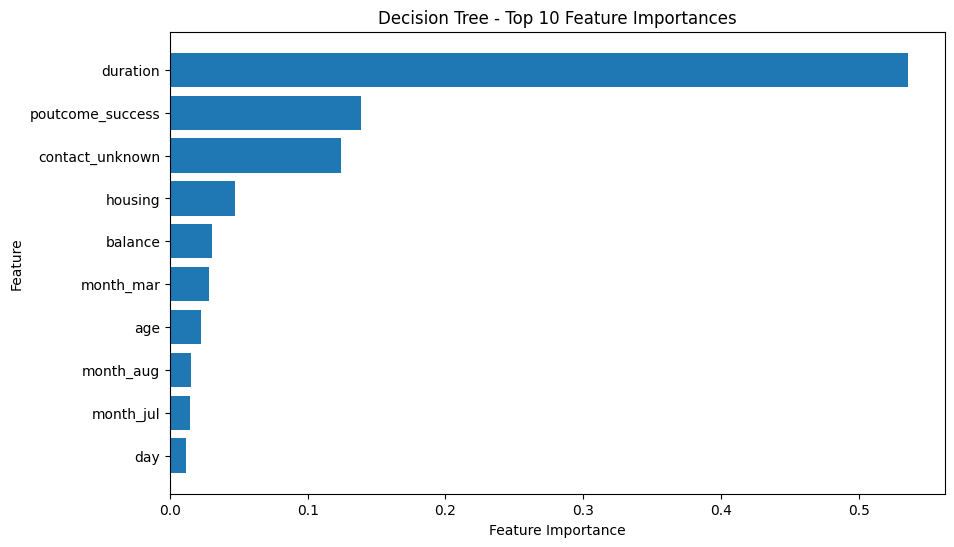

In [ ]:
import matplotlib.pyplot as plt

DT_feature_importance_top = DT_feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    DT_feature_importance_top["Feature"][::-1],
    DT_feature_importance_top["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree - Top 10 Feature Importances")

plt.show()

## Random Forest

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction performance and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
RF_X_train = DT_X_train.copy()
RF_X_test = DT_X_test.copy()

RF_y_train = DT_y_train.copy()
RF_y_test = DT_y_test.copy()

## Random Forest Baseline

We train a baseline Random Forest model before tuning its hyperparameters.

In [ ]:
RF_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

RF_model.fit(RF_X_train, RF_y_train)

RF_y_pred = RF_model.predict(RF_X_test)

In [ ]:
RF_accuracy = accuracy_score(RF_y_test, RF_y_pred)
RF_precision = precision_score(RF_y_test, RF_y_pred)
RF_recall = recall_score(RF_y_test, RF_y_pred)
RF_f1 = f1_score(RF_y_test, RF_y_pred)

print("Random Forest Baseline")
print("---------------------")
print("Accuracy :", RF_accuracy)
print("Precision:", RF_precision)
print("Recall   :", RF_recall)
print("F1 Score :", RF_f1)

Random Forest Baseline
---------------------
Accuracy : 0.8584863412449619
Precision: 0.8271604938271605
Recall   : 0.8865784499054821
F1 Score : 0.8558394160583942


## Random Forest Number of Trees

We evaluate different numbers of trees to find a suitable ensemble size.

In [ ]:
RF_n_estimators_values = [50, 100, 200, 300, 500]

RF_n_estimators_results = {}

for n in RF_n_estimators_values:

    RF_n_estimators_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    RF_n_estimators_model.fit(RF_X_train, RF_y_train)

    RF_n_estimators_pred = RF_n_estimators_model.predict(RF_X_test)

    RF_n_estimators_results[n] = {
        "RF_n_estimators_Accuracy": accuracy_score(
            RF_y_test, RF_n_estimators_pred
        ),
        "RF_n_estimators_Precision": precision_score(
            RF_y_test, RF_n_estimators_pred
        ),
        "RF_n_estimators_Recall": recall_score(
            RF_y_test, RF_n_estimators_pred
        ),
        "RF_n_estimators_F1": f1_score(
            RF_y_test, RF_n_estimators_pred
        )
    }

for n, results in RF_n_estimators_results.items():

    print(f"\nn_estimators: {n}")
    print(f"Accuracy : {results['RF_n_estimators_Accuracy']:.4f}")
    print(f"Precision: {results['RF_n_estimators_Precision']:.4f}")
    print(f"Recall   : {results['RF_n_estimators_Recall']:.4f}")
    print(f"F1       : {results['RF_n_estimators_F1']:.4f}")


n_estimators: 50
Accuracy : 0.8545
Precision: 0.8246
Recall   : 0.8800
F1       : 0.8514

n_estimators: 100
Accuracy : 0.8580
Precision: 0.8287
Recall   : 0.8828
F1       : 0.8549

n_estimators: 200
Accuracy : 0.8585
Precision: 0.8272
Recall   : 0.8866
F1       : 0.8558

n_estimators: 300
Accuracy : 0.8585
Precision: 0.8272
Recall   : 0.8866
F1       : 0.8558

n_estimators: 500
Accuracy : 0.8580
Precision: 0.8241
Recall   : 0.8904
F1       : 0.8560


## Random Forest - Fine Tuning Number of Trees

We fine-tune the number of trees around the best-performing range.

In [ ]:
RF_n_estimators_fine_values = [250, 300, 350, 400, 450, 500, 550, 600]

RF_n_estimators_fine_results = {}

for n in RF_n_estimators_fine_values:

    RF_n_estimators_fine_model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    RF_n_estimators_fine_model.fit(
        RF_X_train,
        RF_y_train
    )

    RF_n_estimators_fine_pred = (
        RF_n_estimators_fine_model.predict(RF_X_test)
    )

    RF_n_estimators_fine_results[n] = {
        "RF_fine_Accuracy": accuracy_score(
            RF_y_test, RF_n_estimators_fine_pred
        ),
        "RF_fine_Precision": precision_score(
            RF_y_test, RF_n_estimators_fine_pred
        ),
        "RF_fine_Recall": recall_score(
            RF_y_test, RF_n_estimators_fine_pred
        ),
        "RF_fine_F1": f1_score(
            RF_y_test, RF_n_estimators_fine_pred
        )
    }

for n, results in RF_n_estimators_fine_results.items():

    print(f"\nn_estimators: {n}")
    print(f"Accuracy : {results['RF_fine_Accuracy']:.4f}")
    print(f"Precision: {results['RF_fine_Precision']:.4f}")
    print(f"Recall   : {results['RF_fine_Recall']:.4f}")
    print(f"F1       : {results['RF_fine_F1']:.4f}")


n_estimators: 250
Accuracy : 0.8589
Precision: 0.8267
Recall   : 0.8885
F1       : 0.8565

n_estimators: 300
Accuracy : 0.8585
Precision: 0.8272
Recall   : 0.8866
F1       : 0.8558

n_estimators: 350
Accuracy : 0.8594
Precision: 0.8257
Recall   : 0.8913
F1       : 0.8573

n_estimators: 400
Accuracy : 0.8576
Precision: 0.8240
Recall   : 0.8894
F1       : 0.8555

n_estimators: 450
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

n_estimators: 500
Accuracy : 0.8580
Precision: 0.8241
Recall   : 0.8904
F1       : 0.8560

n_estimators: 550
Accuracy : 0.8585
Precision: 0.8243
Recall   : 0.8913
F1       : 0.8565

n_estimators: 600
Accuracy : 0.8585
Precision: 0.8237
Recall   : 0.8922
F1       : 0.8566


## Random Forest Max Depth

We evaluate different tree depths while keeping the number of trees fixed.

In [ ]:
RF_max_depth_values = [5, 8, 10, 12, 15, 20, 25, 30, None]

RF_max_depth_results = {}

for depth in RF_max_depth_values:

    RF_max_depth_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    RF_max_depth_model.fit(RF_X_train, RF_y_train)

    RF_max_depth_pred = RF_max_depth_model.predict(RF_X_test)

    RF_max_depth_results[str(depth)] = {
        "RF_depth_Accuracy": accuracy_score(
            RF_y_test, RF_max_depth_pred
        ),
        "RF_depth_Precision": precision_score(
            RF_y_test, RF_max_depth_pred
        ),
        "RF_depth_Recall": recall_score(
            RF_y_test, RF_max_depth_pred
        ),
        "RF_depth_F1": f1_score(
            RF_y_test, RF_max_depth_pred
        )
    }

for depth, results in RF_max_depth_results.items():

    print(f"\nMax Depth: {depth}")
    print(f"Accuracy : {results['RF_depth_Accuracy']:.4f}")
    print(f"Precision: {results['RF_depth_Precision']:.4f}")
    print(f"Recall   : {results['RF_depth_Recall']:.4f}")
    print(f"F1       : {results['RF_depth_F1']:.4f}")


Max Depth: 5
Accuracy : 0.8146
Precision: 0.8114
Recall   : 0.7930
F1       : 0.8021

Max Depth: 8
Accuracy : 0.8446
Precision: 0.8206
Recall   : 0.8601
F1       : 0.8399

Max Depth: 10
Accuracy : 0.8459
Precision: 0.8159
Recall   : 0.8715
F1       : 0.8428

Max Depth: 12
Accuracy : 0.8486
Precision: 0.8163
Recall   : 0.8781
F1       : 0.8461

Max Depth: 15
Accuracy : 0.8576
Precision: 0.8217
Recall   : 0.8932
F1       : 0.8560

Max Depth: 20
Accuracy : 0.8589
Precision: 0.8256
Recall   : 0.8904
F1       : 0.8568

Max Depth: 25
Accuracy : 0.8594
Precision: 0.8218
Recall   : 0.8979
F1       : 0.8582

Max Depth: 30
Accuracy : 0.8571
Precision: 0.8238
Recall   : 0.8885
F1       : 0.8549

Max Depth: None
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552


## Random Forest Min Samples Split

We evaluate different values of `min_samples_split` while keeping the selected `n_estimators` and `max_depth` fixed.

In [ ]:
RF_split_values = [2, 5, 10, 20, 50, 100, 200]

RF_split_results = {}

for split in RF_split_values:

    RF_split_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=split,
        random_state=42,
        n_jobs=-1
    )

    RF_split_model.fit(RF_X_train, RF_y_train)

    RF_split_pred = RF_split_model.predict(RF_X_test)

    RF_split_results[split] = {
        "RF_split_Accuracy": accuracy_score(RF_y_test, RF_split_pred),
        "RF_split_Precision": precision_score(RF_y_test, RF_split_pred),
        "RF_split_Recall": recall_score(RF_y_test, RF_split_pred),
        "RF_split_F1": f1_score(RF_y_test, RF_split_pred)
    }

for split, results in RF_split_results.items():

    print(f"\nMin Samples Split: {split}")
    print(f"Accuracy : {results['RF_split_Accuracy']:.4f}")
    print(f"Precision: {results['RF_split_Precision']:.4f}")
    print(f"Recall   : {results['RF_split_Recall']:.4f}")
    print(f"F1       : {results['RF_split_F1']:.4f}")


Min Samples Split: 2
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Min Samples Split: 5
Accuracy : 0.8589
Precision: 0.8216
Recall   : 0.8970
F1       : 0.8577

Min Samples Split: 10
Accuracy : 0.8598
Precision: 0.8225
Recall   : 0.8979
F1       : 0.8586

Min Samples Split: 20
Accuracy : 0.8585
Precision: 0.8193
Recall   : 0.8998
F1       : 0.8577

Min Samples Split: 50
Accuracy : 0.8558
Precision: 0.8156
Recall   : 0.8989
F1       : 0.8552

Min Samples Split: 100
Accuracy : 0.8549
Precision: 0.8164
Recall   : 0.8951
F1       : 0.8539

Min Samples Split: 200
Accuracy : 0.8446
Precision: 0.8089
Recall   : 0.8800
F1       : 0.8429


## Random Forest Min Samples Leaf

We evaluate different values of `min_samples_leaf` while keeping the selected hyperparameters fixed. Recall is used as the primary evaluation metric.

In [ ]:
RF_leaf_values = [1, 2, 5, 10, 20, 30, 50, 100]

RF_leaf_results = {}

for leaf in RF_leaf_values:

    RF_leaf_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    RF_leaf_model.fit(RF_X_train, RF_y_train)

    RF_leaf_pred = RF_leaf_model.predict(RF_X_test)

    RF_leaf_results[leaf] = {
        "RF_leaf_Accuracy": accuracy_score(
            RF_y_test, RF_leaf_pred
        ),
        "RF_leaf_Precision": precision_score(
            RF_y_test, RF_leaf_pred
        ),
        "RF_leaf_Recall": recall_score(
            RF_y_test, RF_leaf_pred
        ),
        "RF_leaf_F1": f1_score(
            RF_y_test, RF_leaf_pred
        )
    }

for leaf, results in RF_leaf_results.items():

    print(f"\nMin Samples Leaf: {leaf}")
    print(f"Accuracy : {results['RF_leaf_Accuracy']:.4f}")
    print(f"Precision: {results['RF_leaf_Precision']:.4f}")
    print(f"Recall   : {results['RF_leaf_Recall']:.4f}")
    print(f"F1       : {results['RF_leaf_F1']:.4f}")


Min Samples Leaf: 1
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Min Samples Leaf: 2
Accuracy : 0.8589
Precision: 0.8233
Recall   : 0.8941
F1       : 0.8573

Min Samples Leaf: 5
Accuracy : 0.8571
Precision: 0.8194
Recall   : 0.8960
F1       : 0.8560

Min Samples Leaf: 10
Accuracy : 0.8486
Precision: 0.8136
Recall   : 0.8828
F1       : 0.8468

Min Samples Leaf: 20
Accuracy : 0.8419
Precision: 0.8111
Recall   : 0.8686
F1       : 0.8389

Min Samples Leaf: 30
Accuracy : 0.8356
Precision: 0.8055
Recall   : 0.8611
F1       : 0.8323

Min Samples Leaf: 50
Accuracy : 0.8298
Precision: 0.8060
Recall   : 0.8440
F1       : 0.8246

Min Samples Leaf: 100
Accuracy : 0.8128
Precision: 0.7996
Recall   : 0.8072
F1       : 0.8034


## Random Forest Max Features

We evaluate different `max_features` strategies while keeping the selected hyperparameters fixed. Recall is used as the primary evaluation metric.

In [ ]:
RF_max_features_values = ["sqrt", "log2", None]

RF_max_features_results = {}

for max_features in RF_max_features_values:

    RF_max_features_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    RF_max_features_model.fit(RF_X_train, RF_y_train)

    RF_max_features_pred = RF_max_features_model.predict(RF_X_test)

    RF_max_features_results[str(max_features)] = {
        "RF_features_Accuracy": accuracy_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_Precision": precision_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_Recall": recall_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_F1": f1_score(
            RF_y_test, RF_max_features_pred
        )
    }

for max_features, results in RF_max_features_results.items():

    print(f"\nMax Features: {max_features}")
    print(f"Accuracy : {results['RF_features_Accuracy']:.4f}")
    print(f"Precision: {results['RF_features_Precision']:.4f}")
    print(f"Recall   : {results['RF_features_Recall']:.4f}")
    print(f"F1       : {results['RF_features_F1']:.4f}")


Max Features: sqrt
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Max Features: log2
Accuracy : 0.8598
Precision: 0.8248
Recall   : 0.8941
F1       : 0.8580

Max Features: None
Accuracy : 0.8576
Precision: 0.8246
Recall   : 0.8885
F1       : 0.8553


## Random Forest Max Features

We evaluate different `max_features` strategies while keeping the selected hyperparameters fixed. Recall is used as the primary evaluation metric.


In [ ]:
RF_max_features_values = ["sqrt", "log2", None]

RF_max_features_results = {}

for max_features in RF_max_features_values:

    RF_max_features_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    RF_max_features_model.fit(RF_X_train, RF_y_train)

    RF_max_features_pred = RF_max_features_model.predict(RF_X_test)

    RF_max_features_results[str(max_features)] = {
        "RF_features_Accuracy": accuracy_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_Precision": precision_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_Recall": recall_score(
            RF_y_test, RF_max_features_pred
        ),
        "RF_features_F1": f1_score(
            RF_y_test, RF_max_features_pred
        )
    }

for max_features, results in RF_max_features_results.items():

    print(f"\nMax Features: {max_features}")
    print(f"Accuracy : {results['RF_features_Accuracy']:.4f}")
    print(f"Precision: {results['RF_features_Precision']:.4f}")
    print(f"Recall   : {results['RF_features_Recall']:.4f}")
    print(f"F1       : {results['RF_features_F1']:.4f}")


Max Features: sqrt
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Max Features: log2
Accuracy : 0.8598
Precision: 0.8248
Recall   : 0.8941
F1       : 0.8580

Max Features: None
Accuracy : 0.8576
Precision: 0.8246
Recall   : 0.8885
F1       : 0.8553


## Random Forest Criterion

We evaluate different splitting criteria while keeping the selected hyperparameters fixed. Recall is used as the primary evaluation metric.

In [ ]:
RF_criterion_values = ["gini", "entropy", "log_loss"]

RF_criterion_results = {}

for criterion in RF_criterion_values:

    RF_criterion_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        criterion=criterion,
        random_state=42,
        n_jobs=-1
    )

    RF_criterion_model.fit(RF_X_train, RF_y_train)

    RF_criterion_pred = RF_criterion_model.predict(RF_X_test)

    RF_criterion_results[criterion] = {
        "RF_criterion_Accuracy": accuracy_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_Precision": precision_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_Recall": recall_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_F1": f1_score(
            RF_y_test, RF_criterion_pred
        )
    }

for criterion, results in RF_criterion_results.items():

    print(f"\nCriterion: {criterion}")
    print(f"Accuracy : {results['RF_criterion_Accuracy']:.4f}")
    print(f"Precision: {results['RF_criterion_Precision']:.4f}")
    print(f"Recall   : {results['RF_criterion_Recall']:.4f}")
    print(f"F1       : {results['RF_criterion_F1']:.4f}")


Criterion: gini
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Criterion: entropy
Accuracy : 0.8612
Precision: 0.8264
Recall   : 0.8951
F1       : 0.8593

Criterion: log_loss
Accuracy : 0.8612
Precision: 0.8264
Recall   : 0.8951
F1       : 0.8593


## Random Forest Criterion

We evaluate different splitting criteria while keeping the selected hyperparameters fixed. Recall is used as the primary evaluation metric.

In [ ]:
RF_criterion_values = ["gini", "entropy", "log_loss"]

RF_criterion_results = {}

for criterion in RF_criterion_values:

    RF_criterion_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        criterion=criterion,
        random_state=42,
        n_jobs=-1
    )

    RF_criterion_model.fit(RF_X_train, RF_y_train)

    RF_criterion_pred = RF_criterion_model.predict(RF_X_test)

    RF_criterion_results[criterion] = {
        "RF_criterion_Accuracy": accuracy_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_Precision": precision_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_Recall": recall_score(
            RF_y_test, RF_criterion_pred
        ),
        "RF_criterion_F1": f1_score(
            RF_y_test, RF_criterion_pred
        )
    }

for criterion, results in RF_criterion_results.items():

    print(f"\nCriterion: {criterion}")
    print(f"Accuracy : {results['RF_criterion_Accuracy']:.4f}")
    print(f"Precision: {results['RF_criterion_Precision']:.4f}")
    print(f"Recall   : {results['RF_criterion_Recall']:.4f}")
    print(f"F1       : {results['RF_criterion_F1']:.4f}")


Criterion: gini
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Criterion: entropy
Accuracy : 0.8612
Precision: 0.8264
Recall   : 0.8951
F1       : 0.8593

Criterion: log_loss
Accuracy : 0.8612
Precision: 0.8264
Recall   : 0.8951
F1       : 0.8593


## Random Forest Class Weight

We evaluate different class-weighting strategies to improve the detection of potential deposit customers. Recall is used as the primary evaluation metric.

In [ ]:
RF_class_weight_values = [None, "balanced", "balanced_subsample"]

RF_class_weight_results = {}

for class_weight in RF_class_weight_values:

    RF_class_weight_model = RandomForestClassifier(
        n_estimators=450,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        criterion="gini",
        class_weight=class_weight,
        random_state=42,
        n_jobs=-1
    )

    RF_class_weight_model.fit(RF_X_train, RF_y_train)

    RF_class_weight_pred = RF_class_weight_model.predict(
        RF_X_test
    )

    RF_class_weight_results[str(class_weight)] = {
        "RF_weight_Accuracy": accuracy_score(
            RF_y_test, RF_class_weight_pred
        ),
        "RF_weight_Precision": precision_score(
            RF_y_test, RF_class_weight_pred
        ),
        "RF_weight_Recall": recall_score(
            RF_y_test, RF_class_weight_pred
        ),
        "RF_weight_F1": f1_score(
            RF_y_test, RF_class_weight_pred
        )
    }

for weight, results in RF_class_weight_results.items():

    print(f"\nClass Weight: {weight}")
    print(f"Accuracy : {results['RF_weight_Accuracy']:.4f}")
    print(f"Precision: {results['RF_weight_Precision']:.4f}")
    print(f"Recall   : {results['RF_weight_Recall']:.4f}")
    print(f"F1       : {results['RF_weight_F1']:.4f}")


Class Weight: None
Accuracy : 0.8576
Precision: 0.8251
Recall   : 0.8875
F1       : 0.8552

Class Weight: balanced
Accuracy : 0.8607
Precision: 0.8256
Recall   : 0.8951
F1       : 0.8590

Class Weight: balanced_subsample
Accuracy : 0.8576
Precision: 0.8234
Recall   : 0.8904
F1       : 0.8556


## Random Forest Hyperparameter Optimization

We use RandomizedSearchCV to find the best combination of Random Forest hyperparameters. Recall is used as the primary scoring metric because the main objective is to identify as many potential deposit customers as possible.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

RF_param_grid = {
    "n_estimators": [300, 400, 450, 500, 600],
    "max_depth": [10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy", "log_loss"],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

RF_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=RF_param_grid,
    n_iter=30,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

RF_random_search.fit(RF_X_train, RF_y_train)

print("Best Parameters:")
print(RF_random_search.best_params_)

print("\nBest CV Recall:")
print(RF_random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy', 'class_weight': 'balanced'}

Best CV Recall:
0.8919889695518324


In [ ]:
RF_final_model = RF_random_search.best_estimator_

RF_final_pred = RF_final_model.predict(RF_X_test)

RF_final_accuracy = accuracy_score(RF_y_test, RF_final_pred)
RF_final_precision = precision_score(RF_y_test, RF_final_pred)
RF_final_recall = recall_score(RF_y_test, RF_final_pred)
RF_final_f1 = f1_score(RF_y_test, RF_final_pred)

RF_final_cm = confusion_matrix(RF_y_test, RF_final_pred)

print("Final Random Forest Results")
print("---------------------------")
print("Accuracy :", RF_final_accuracy)
print("Precision:", RF_final_precision)
print("Recall   :", RF_final_recall)
print("F1 Score :", RF_final_f1)

print("\nConfusion Matrix:")
print(RF_final_cm)

print("\nClassification Report:")
print(classification_report(RF_y_test, RF_final_pred))

Final Random Forest Results
---------------------------
Accuracy : 0.8575906851768921
Precision: 0.814625850340136
Recall   : 0.9054820415879017
F1 Score : 0.8576544315129812

Confusion Matrix:
[[957 218]
 [100 958]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1175
           1       0.81      0.91      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



## Random Forest Hyperparameter Optimization for Accuracy

We use RandomizedSearchCV to find the best combination of Random Forest hyperparameters based on Accuracy. This optimization is performed separately from the Recall-based optimization.

In [ ]:
RF_accuracy_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    param_distributions=RF_param_grid,

    n_iter=30,

    scoring="accuracy",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

RF_accuracy_search.fit(RF_X_train, RF_y_train)

print("Best Parameters for Accuracy:")
print(RF_accuracy_search.best_params_)

print("\nBest CV Accuracy:")
print(RF_accuracy_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters for Accuracy:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 25, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}

Best CV Accuracy:
0.8504869809065843


In [ ]:
RF_accuracy_final_model = RF_accuracy_search.best_estimator_

RF_accuracy_final_pred = RF_accuracy_final_model.predict(
    RF_X_test
)

RF_accuracy_final_accuracy = accuracy_score(
    RF_y_test,
    RF_accuracy_final_pred
)

RF_accuracy_final_precision = precision_score(
    RF_y_test,
    RF_accuracy_final_pred
)

RF_accuracy_final_recall = recall_score(
    RF_y_test,
    RF_accuracy_final_pred
)

RF_accuracy_final_f1 = f1_score(
    RF_y_test,
    RF_accuracy_final_pred
)

print("Final Random Forest - Accuracy Optimized")
print("----------------------------------------")
print("Accuracy :", RF_accuracy_final_accuracy)
print("Precision:", RF_accuracy_final_precision)
print("Recall   :", RF_accuracy_final_recall)
print("F1 Score :", RF_accuracy_final_f1)

Final Random Forest - Accuracy Optimized
----------------------------------------
Accuracy : 0.8584863412449619
Precision: 0.8192771084337349
Recall   : 0.8998109640831758
F1 Score : 0.8576576576576577


In [ ]:
# Final Random Forest Model optimized for Recall.
# Recall was prioritized because the main objective is to identify the largest possible number of potential customers.

In [ ]:
from xgboost import XGBClassifier

XGB_X_train = RF_X_train.copy()
XGB_X_test = RF_X_test.copy()

XGB_y_train = RF_y_train.copy()
XGB_y_test = RF_y_test.copy()


XGB_model = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

XGB_model.fit(XGB_X_train, XGB_y_train)
XGB_y_pred = XGB_model.predict(XGB_X_test)

In [ ]:
XGB_accuracy = accuracy_score(XGB_y_test, XGB_y_pred)
XGB_precision = precision_score(XGB_y_test, XGB_y_pred)
XGB_recall = recall_score(XGB_y_test, XGB_y_pred)
XGB_f1 = f1_score(XGB_y_test, XGB_y_pred)

print("XGBoost Baseline")
print("----------------")
print("Accuracy :", XGB_accuracy)
print("Precision:", XGB_precision)
print("Recall   :", XGB_recall)
print("F1 Score :", XGB_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(XGB_y_test, XGB_y_pred))

XGBoost Baseline
----------------
Accuracy : 0.8602776533811016
Precision: 0.8403284671532847
Recall   : 0.8705103969754253
F1 Score : 0.8551532033426184

Confusion Matrix:
[[1000  175]
 [ 137  921]]


In [ ]:
## XGBoost Learning Rate
# We evaluate different learning rates while keeping other hyperparameters at default.

XGB_lr_values = [0.01, 0.05, 0.1, 0.2, 0.3]
XGB_lr_results = {}

for lr in XGB_lr_values:
    XGB_lr_model = XGBClassifier(
        n_estimators=200,
        learning_rate=lr,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
    XGB_lr_model.fit(XGB_X_train, XGB_y_train)
    XGB_lr_pred = XGB_lr_model.predict(XGB_X_test)

    XGB_lr_results[lr] = {
        "XGB_lr_Accuracy": accuracy_score(XGB_y_test, XGB_lr_pred),
        "XGB_lr_Precision": precision_score(XGB_y_test, XGB_lr_pred),
        "XGB_lr_Recall": recall_score(XGB_y_test, XGB_lr_pred),
        "XGB_lr_F1": f1_score(XGB_y_test, XGB_lr_pred)
    }

pd.DataFrame(XGB_lr_results).T

,XGB_lr_Accuracy,XGB_lr_Precision,XGB_lr_Recall,XGB_lr_F1
0.01,0.842812,0.816473,0.862004,0.838621
0.05,0.866995,0.840036,0.888469,0.863574
0.10,0.867443,0.843243,0.884688,0.863469
0.20,0.865204,0.839462,0.884688,0.861482
0.30,0.860278,0.840328,0.870510,0.855153


In [ ]:
## XGBoost Hyperparameter Optimization
# We use RandomizedSearchCV to find the best combination of hyperparameters.
# Recall is used as the primary scoring metric, consistent with the RF section.

XGB_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "scale_pos_weight": [1, (XGB_y_train == 0).sum() / (XGB_y_train == 1).sum()]
}

XGB_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=-1),
    param_distributions=XGB_param_grid,
    n_iter=30,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

XGB_random_search.fit(XGB_X_train, XGB_y_train)

print("Best Parameters:", XGB_random_search.best_params_)
print("Best CV Recall:", XGB_random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': np.float64(1.1103757976837627), 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}
Best CV Recall: 0.8893865429648795


In [ ]:
# Final XGBoost model optimized for Recall.
# Recall was prioritized because the main objective is to identify
# the largest possible number of potential customers.

XGB_final_model = XGB_random_search.best_estimator_
XGB_final_pred = XGB_final_model.predict(XGB_X_test)

XGB_final_accuracy = accuracy_score(XGB_y_test, XGB_final_pred)
XGB_final_precision = precision_score(XGB_y_test, XGB_final_pred)
XGB_final_recall = recall_score(XGB_y_test, XGB_final_pred)
XGB_final_f1 = f1_score(XGB_y_test, XGB_final_pred)

XGB_final_cm = confusion_matrix(XGB_y_test, XGB_final_pred)

print("Final XGBoost Results")
print("----------------------")
print("Accuracy :", XGB_final_accuracy)
print("Precision:", XGB_final_precision)
print("Recall   :", XGB_final_recall)
print("F1 Score :", XGB_final_f1)

print("\nConfusion Matrix:")
print(XGB_final_cm)

Final XGBoost Results
----------------------
Accuracy : 0.8701298701298701
Precision: 0.8380281690140845
Recall   : 0.8998109640831758
F1 Score : 0.8678213309024613

Confusion Matrix:
[[991 184]
 [106 952]]


In [ ]:
from lightgbm import LGBMClassifier

LGBM_X_train = RF_X_train.copy()
LGBM_X_test = RF_X_test.copy()

LGBM_y_train = RF_y_train.copy()
LGBM_y_test = RF_y_test.copy()

LGBM_model = LGBMClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

LGBM_model.fit(LGBM_X_train, LGBM_y_train)
LGBM_y_pred = LGBM_model.predict(LGBM_X_test)

In [ ]:
LGBM_accuracy = accuracy_score(LGBM_y_test, LGBM_y_pred)
LGBM_precision = precision_score(LGBM_y_test, LGBM_y_pred)
LGBM_recall = recall_score(LGBM_y_test, LGBM_y_pred)
LGBM_f1 = f1_score(LGBM_y_test, LGBM_y_pred)

print("LightGBM Baseline")
print("-----------------")
print("Accuracy :", LGBM_accuracy)
print("Precision:", LGBM_precision)
print("Recall   :", LGBM_recall)
print("F1 Score :", LGBM_f1)

print("\nConfusion Matrix:")
print(confusion_matrix(LGBM_y_test, LGBM_y_pred))

LightGBM Baseline
-----------------
Accuracy : 0.8656515897895208
Precision: 0.839605734767025
Recall   : 0.8856332703213611
F1 Score : 0.8620055197792088

Confusion Matrix:
[[996 179]
 [121 937]]


In [ ]:
## LightGBM Hyperparameter Optimization
# We use RandomizedSearchCV to find the best combination of hyperparameters.
# Recall is used as the primary scoring metric, consistent with RF/XGBoost.

LGBM_param_grid = {
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 8, -1],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 50, 70],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "scale_pos_weight": [1, (LGBM_y_train == 0).sum() / (LGBM_y_train == 1).sum()]
}

LGBM_random_search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=LGBM_param_grid,
    n_iter=30,
    scoring="recall",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

LGBM_random_search.fit(LGBM_X_train, LGBM_y_train)

print("Best Parameters:", LGBM_random_search.best_params_)
print("Best CV Recall:", LGBM_random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': np.float64(1.1103757976837627), 'num_leaves': 15, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best CV Recall: 0.8900943672703827


In [ ]:
LGBM_final_model=LGBM_random_search.best_estimator_

In [ ]:
LGBM_proba=LGBM_final_model.predict_proba(LGBM_X_test)[:,1]

for threshold in [0.2,0.3,0.4,0.5]:
    pred=(LGBM_proba>=threshold).astype(int)
    print(f"Threshold={threshold}")
    print("Precision:",precision_score(LGBM_y_test,pred))
    print("Recall:",recall_score(LGBM_y_test,pred))
    print("F1-score:",f1_score(LGBM_y_test,pred))
    print()

Threshold=0.2
Precision: 0.7351694915254238
Recall: 0.9839319470699432
F1-score: 0.841552142279709

Threshold=0.3
Precision: 0.7801526717557252
Recall: 0.9659735349716446
F1-score: 0.8631756756756757

Threshold=0.4
Precision: 0.8062953995157385
Recall: 0.944234404536862
F1-score: 0.8698302133217239

Threshold=0.5
Precision: 0.8274067649609714
Recall: 0.9017013232514177
F1-score: 0.8629579375848032



In [ ]:
LGBM_final_model = LGBM_random_search.best_estimator_
LGBM_final_pred = LGBM_final_model.predict(LGBM_X_test)

LGBM_final_accuracy = accuracy_score(LGBM_y_test, LGBM_final_pred)
LGBM_final_precision = precision_score(LGBM_y_test, LGBM_final_pred)
LGBM_final_recall = recall_score(LGBM_y_test, LGBM_final_pred)
LGBM_final_f1 = f1_score(LGBM_y_test, LGBM_final_pred)

LGBM_final_cm = confusion_matrix(LGBM_y_test, LGBM_final_pred)

print("Final LightGBM Results (Threshold = 0.5)")
print("------------------------------------------")
print("Accuracy :", LGBM_final_accuracy)
print("Precision:", LGBM_final_precision)
print("Recall   :", LGBM_final_recall)
print("F1 Score :", LGBM_final_f1)

print("\nConfusion Matrix:")
print(LGBM_final_cm)

Final LightGBM Results (Threshold = 0.5)
------------------------------------------
Accuracy : 0.864308105687416
Precision: 0.8274067649609714
Recall   : 0.9017013232514177
F1 Score : 0.8629579375848032

Confusion Matrix:
[[976 199]
 [104 954]]


                                Model  Accuracy  Precision  Recall  F1-score  \
0    Random Forest (Recall-Optimized)    0.8576     0.8146  0.9055    0.8577   
1         LightGBM (Recall-Optimized)    0.8643     0.8274  0.9017    0.8630   
2          XGBoost (Recall-Optimized)    0.8701     0.8380  0.8998    0.8678   
3  Random Forest (Accuracy-Optimized)    0.8585     0.8193  0.8998    0.8577   
4               Decision Tree (Final)    0.8146     0.7860  0.8365    0.8104   
5      Logistic Regression (Balanced)    0.8285     0.8205  0.8166    0.8186   
6       Logistic Regression (Default)    0.8267     0.8273  0.8015    0.8142   
7                         KNN (Tuned)    0.7936     0.7890  0.7703    0.7795   

   ROC-AUC  
0   0.9233  
1   0.9318  
2   0.9281  
3   0.9213  
4   0.8919  
5   0.9070  
6   0.9070  
7   0.8725  


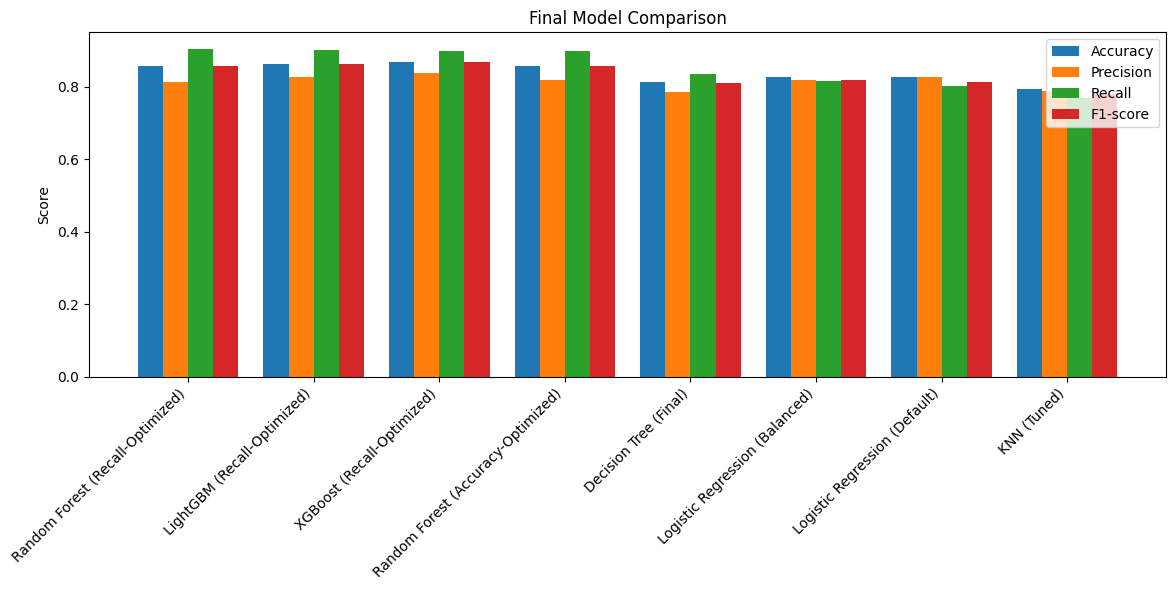

In [ ]:
# ============================================
# Final Comparison - All Models
# ============================================

final_model_names = [
    "Logistic Regression (Default)",
    "Logistic Regression (Balanced)",
    "KNN (Tuned)",
    "Decision Tree (Final)",
    "Random Forest (Recall-Optimized)",
    "Random Forest (Accuracy-Optimized)",
    "XGBoost (Recall-Optimized)",
    "LightGBM (Recall-Optimized)"
]

final_accuracy = [
    accuracy_score(LR_y_test, LR_predictions),
    accuracy_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_accuracy,
    DT_final_accuracy,
    RF_final_accuracy,
    RF_accuracy_final_accuracy,
    XGB_final_accuracy,
    LGBM_final_accuracy
]

final_precision = [
    precision_score(LR_y_test, LR_predictions),
    precision_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_precision,
    DT_final_precision,
    RF_final_precision,
    RF_accuracy_final_precision,
    XGB_final_precision,
    LGBM_final_precision
]

final_recall = [
    recall_score(LR_y_test, LR_predictions),
    recall_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_recall,
    DT_final_recall,
    RF_final_recall,
    RF_accuracy_final_recall,
    XGB_final_recall,
    LGBM_final_recall
]

final_f1 = [
    f1_score(LR_y_test, LR_predictions),
    f1_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_f1,
    DT_final_f1,
    RF_final_f1,
    RF_accuracy_final_f1,
    XGB_final_f1,
    LGBM_final_f1
]

final_roc_auc = [
    roc_auc_score(LR_y_test, LR_proba),
    roc_auc_score(LR_y_test, LR_proba_balanced),
    roc_auc_score(KNN_y_test, KNN_grid_best_model.predict_proba(KNN_X_test)[:, 1]),
    roc_auc_score(DT_y_test, DT_final_model.predict_proba(DT_X_test)[:, 1]),
    roc_auc_score(RF_y_test, RF_final_model.predict_proba(RF_X_test)[:, 1]),
    roc_auc_score(RF_y_test, RF_accuracy_final_model.predict_proba(RF_X_test)[:, 1]),
    roc_auc_score(XGB_y_test, XGB_final_model.predict_proba(XGB_X_test)[:, 1]),
    roc_auc_score(LGBM_y_test, LGBM_proba)
]

final_comparison = pd.DataFrame({
    "Model": final_model_names,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-score": final_f1,
    "ROC-AUC": final_roc_auc
})

# Sort by Recall because it is the primary metric
final_comparison = final_comparison.sort_values(
    by="Recall", ascending=False
).reset_index(drop=True)

print(final_comparison.round(4))

# ============================================
# Model Comparison Plot
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_comparison))
width = 0.2

ax.bar(x - 1.5 * width, final_comparison["Accuracy"], width, label="Accuracy")
ax.bar(x - 0.5 * width, final_comparison["Precision"], width, label="Precision")
ax.bar(x + 0.5 * width, final_comparison["Recall"], width, label="Recall")
ax.bar(x + 1.5 * width, final_comparison["F1-score"], width, label="F1-score")

ax.set_xticks(x)
ax.set_xticklabels(final_comparison["Model"], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Final Model Comparison")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:


# ==========================================
# 1. Split training data into train + validation
# ==========================================

X_rf_train, X_rf_val, y_rf_train, y_rf_val = train_test_split(
    RF_X_train,
    RF_y_train,
    test_size=0.20,
    random_state=42,
    stratify=RF_y_train
)

# ==========================================
# 2. Train your best Random Forest
# ==========================================

RF_class_weight_model.fit(X_rf_train, y_rf_train)

# ==========================================
# 3. Get probabilities on validation set
# ==========================================

y_val_proba = RF_class_weight_model.predict_proba(X_rf_val)[:, 1]

# ==========================================
# 4. Try different thresholds
# ==========================================

results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_val_pred = (y_val_proba >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_rf_val, y_val_pred),
        "Precision": precision_score(y_rf_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_rf_val, y_val_pred, zero_division=0),
        "F1": f1_score(y_rf_val, y_val_pred, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

# ==========================================
# 5. Best threshold according to F1
# ==========================================

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", round(best_threshold, 2))
print("Validation Accuracy:", round(best_threshold_row["Accuracy"] * 100, 2), "%")
print("Validation Precision:", round(best_threshold_row["Precision"] * 100, 2), "%")
print("Validation Recall:", round(best_threshold_row["Recall"] * 100, 2), "%")
print("Validation F1:", round(best_threshold_row["F1"] * 100, 2), "%")

# ==========================================
# 6. Final evaluation on TEST
# ==========================================

y_test_proba = RF_class_weight_model.predict_proba(RF_X_test)[:, 1]

y_test_pred = (y_test_proba >= best_threshold).astype(int)

print("\n===== TEST RESULTS =====")
print("Accuracy:", round(accuracy_score(RF_y_test, y_test_pred) * 100, 2), "%")
print("Precision:", round(precision_score(RF_y_test, y_test_pred, zero_division=0) * 100, 2), "%")
print("Recall:", round(recall_score(RF_y_test, y_test_pred, zero_division=0) * 100, 2), "%")
print("F1:", round(f1_score(RF_y_test, y_test_pred, zero_division=0) * 100, 2), "%")

Best Threshold: 0.46
Validation Accuracy: 84.77 %
Validation Precision: 80.21 %
Validation Recall: 90.07 %
Validation F1: 84.86 %

===== TEST RESULTS =====
Accuracy: 86.12 %
Precision: 81.38 %
Recall: 91.68 %
F1: 86.22 %


In [ ]:
#==========================================
# Best Ensemble Threshold for Accuracy
# ==========================================

best_accuracy_ensemble = ensemble_results.loc[
    ensemble_results["Accuracy"].idxmax()
]

print("===== BEST RF + LIGHTGBM ENSEMBLE FOR ACCURACY =====")
print("Threshold:", best_accuracy_ensemble["Threshold"])
print("Accuracy:", round(best_accuracy_ensemble["Accuracy"] * 100, 2), "%")
print("Precision:", round(best_accuracy_ensemble["Precision"] * 100, 2), "%")
print("Recall:", round(best_accuracy_ensemble["Recall"] * 100, 2), "%")
print("F1:", round(best_accuracy_ensemble["F1"] * 100, 2), "%")

===== BEST RF + LIGHTGBM ENSEMBLE FOR ACCURACY =====
Threshold: 0.35
Accuracy: 86.83 %
Precision: 80.27 %
Recall: 95.75 %
F1: 87.33 %


In [ ]:
# ==========================================
# 1. Get probabilities from both models
# ==========================================

rf_proba = RF_class_weight_model.predict_proba(RF_X_test)[:, 1]
lgbm_proba = LGBM_model.predict_proba(LGBM_X_test)[:, 1]

# ==========================================
# 2. Average probabilities = Soft Voting
# ==========================================

ensemble_proba = (rf_proba + lgbm_proba) / 2

# ==========================================
# 3. Try different thresholds
# ==========================================

ensemble_results = []

for threshold in np.arange(0.10, 0.91, 0.01):

    y_pred = (ensemble_proba >= threshold).astype(int)

    ensemble_results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy_score(RF_y_test, y_pred),
        "Precision": precision_score(RF_y_test, y_pred, zero_division=0),
        "Recall": recall_score(RF_y_test, y_pred, zero_division=0),
        "F1": f1_score(RF_y_test, y_pred, zero_division=0)
    })

ensemble_results = pd.DataFrame(ensemble_results)

# ==========================================
# 4. Highest Accuracy (across all thresholds)
# ==========================================

best_ensemble = ensemble_results.loc[
    ensemble_results["Accuracy"].idxmax()
]

print("===== BEST RF + LIGHTGBM ENSEMBLE (Accuracy-Optimized) =====")
print("Threshold:", best_ensemble["Threshold"])
print("Accuracy:", round(best_ensemble["Accuracy"] * 100, 2), "%")
print("Precision:", round(best_ensemble["Precision"] * 100, 2), "%")
print("Recall:", round(best_ensemble["Recall"] * 100, 2), "%")
print("F1:", round(best_ensemble["F1"] * 100, 2), "%")

===== BEST RF + LIGHTGBM ENSEMBLE (Accuracy-Optimized) =====
Threshold: 0.35
Accuracy: 86.83 %
Precision: 80.27 %
Recall: 95.75 %
F1: 87.33 %


                                         Model  Accuracy  Precision  Recall  \
0  RF + LightGBM Ensemble (Accuracy-Optimized)    0.8683     0.8027  0.9575   
1             Random Forest (Recall-Optimized)    0.8576     0.8146  0.9055   
2                  LightGBM (Recall-Optimized)    0.8643     0.8274  0.9017   
3                   XGBoost (Recall-Optimized)    0.8701     0.8380  0.8998   
4                        Decision Tree (Final)    0.8146     0.7860  0.8365   
5               Logistic Regression (Balanced)    0.8285     0.8205  0.8166   
6                Logistic Regression (Default)    0.8267     0.8273  0.8015   
7                                  KNN (Tuned)    0.7936     0.7890  0.7703   

   F1-score  ROC-AUC  
0    0.8733   0.9289  
1    0.8577   0.9233  
2    0.8630   0.9318  
3    0.8678   0.9281  
4    0.8104   0.8919  
5    0.8186   0.9070  
6    0.8142   0.9070  
7    0.7795   0.8725  


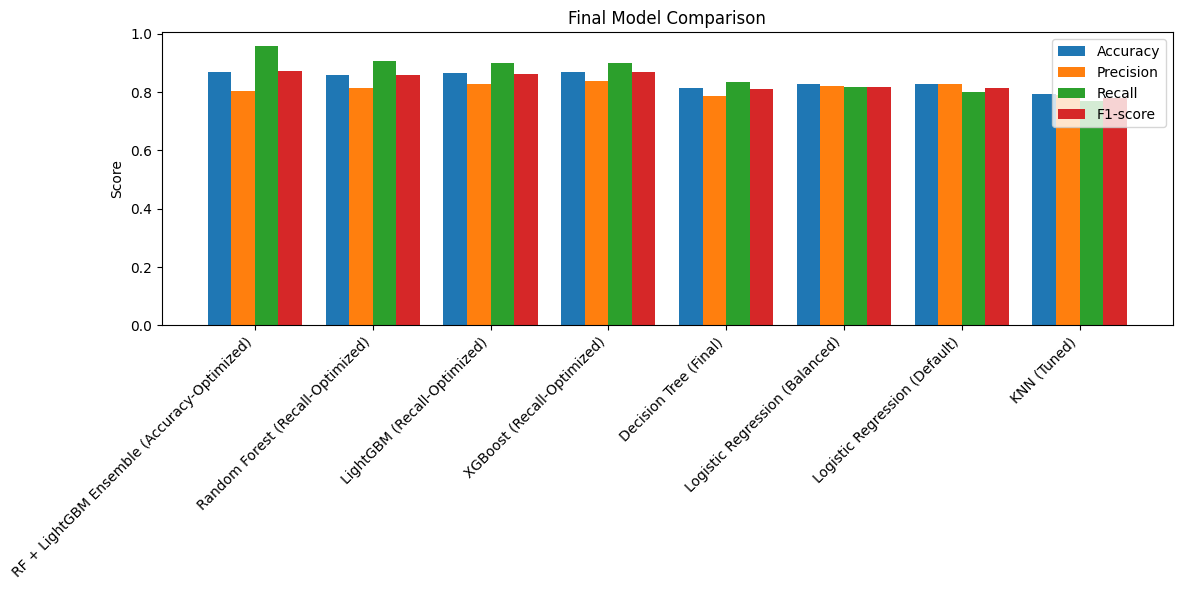

In [ ]:
# ============================================
# Final Comparison - All Models
# ============================================

final_model_names = [
    "Logistic Regression (Default)",
    "Logistic Regression (Balanced)",
    "KNN (Tuned)",
    "Decision Tree (Final)",
    "Random Forest (Recall-Optimized)",
    "XGBoost (Recall-Optimized)",
    "LightGBM (Recall-Optimized)",
    "RF + LightGBM Ensemble (Accuracy-Optimized)"
]

final_accuracy = [
    accuracy_score(LR_y_test, LR_predictions),
    accuracy_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_accuracy,
    DT_final_accuracy,
    RF_final_accuracy,
    XGB_final_accuracy,
    LGBM_final_accuracy,
    best_ensemble["Accuracy"]
]

final_precision = [
    precision_score(LR_y_test, LR_predictions),
    precision_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_precision,
    DT_final_precision,
    RF_final_precision,
    XGB_final_precision,
    LGBM_final_precision,
    best_ensemble["Precision"]
]

final_recall = [
    recall_score(LR_y_test, LR_predictions),
    recall_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_recall,
    DT_final_recall,
    RF_final_recall,
    XGB_final_recall,
    LGBM_final_recall,
    best_ensemble["Recall"]
]

final_f1 = [
    f1_score(LR_y_test, LR_predictions),
    f1_score(LR_y_test, LR_predictions_balanced),
    KNN_grid_f1,
    DT_final_f1,
    RF_final_f1,
    XGB_final_f1,
    LGBM_final_f1,
    best_ensemble["F1"]
]

final_roc_auc = [
    roc_auc_score(LR_y_test, LR_proba),
    roc_auc_score(LR_y_test, LR_proba_balanced),
    roc_auc_score(KNN_y_test, KNN_grid_best_model.predict_proba(KNN_X_test)[:, 1]),
    roc_auc_score(DT_y_test, DT_final_model.predict_proba(DT_X_test)[:, 1]),
    roc_auc_score(RF_y_test, RF_final_model.predict_proba(RF_X_test)[:, 1]),
    roc_auc_score(XGB_y_test, XGB_final_model.predict_proba(XGB_X_test)[:, 1]),
    roc_auc_score(LGBM_y_test, LGBM_proba),
    roc_auc_score(RF_y_test, ensemble_proba)
]

final_comparison = pd.DataFrame({
    "Model": final_model_names,
    "Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1-score": final_f1,
    "ROC-AUC": final_roc_auc
})

# Sort by Recall because it is the primary metric
final_comparison = final_comparison.sort_values(
    by="Recall", ascending=False
).reset_index(drop=True)

print(final_comparison.round(4))

# ============================================
# Model Comparison Plot
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(final_comparison))
width = 0.2

ax.bar(x - 1.5 * width, final_comparison["Accuracy"], width, label="Accuracy")
ax.bar(x - 0.5 * width, final_comparison["Precision"], width, label="Precision")
ax.bar(x + 0.5 * width, final_comparison["Recall"], width, label="Recall")
ax.bar(x + 1.5 * width, final_comparison["F1-score"], width, label="F1-score")

ax.set_xticks(x)
ax.set_xticklabels(final_comparison["Model"], rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_title("Final Model Comparison")
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
best_ensemble = ensemble_results.loc[
    ensemble_results["Accuracy"].idxmax()
]
print("Final Threshold:", best_ensemble["Threshold"])

Final Threshold: 0.35


## Model Deployment Preparation

In this section, we prepare the final trained model for deployment.

The final model is a Soft Voting Ensemble consisting of:
- Random Forest
- LightGBM

The two models' predicted probabilities are averaged, and the final classification uses the optimized threshold of 0.35.

We also save the preprocessing objects used during training:
- OneHotEncoder for categorical features
- StandardScaler for numerical features

These saved components will later be used by the Backend/API to ensure that new customer data is processed exactly as it was during model training.

In [ ]:
import joblib
import json
import os

# Create folder
os.makedirs("saved_models", exist_ok=True)

# Save trained models
joblib.dump(RF_class_weight_model, "saved_models/rf_model.joblib")
joblib.dump(LGBM_model, "saved_models/lgbm_model.joblib")

# Save preprocessing objects
joblib.dump(LR_encoder, "saved_models/encoder.joblib")
joblib.dump(LR_scaler, "saved_models/scaler.joblib")

# Save ensemble configuration
config = {
    "threshold": 0.35,
    "categorical_columns": LR_multi_cat_cols,
    "numerical_columns": LR_numerical_cols
}

with open("saved_models/config.json", "w") as f:
    json.dump(config, f, indent=4)

print("✅ All model files saved successfully!")

✅ All model files saved successfully!


## Verify Saved Model

In this section, we reload the saved models and preprocessing objects
to verify that the deployment files were saved correctly.

The reloaded models should produce the same predictions as the original
trained models.

In [ ]:
# ==========================================
# Verify Saved Models
# ==========================================

import joblib
import json

# Load saved models
rf_loaded = joblib.load("saved_models/rf_model.joblib")
lgbm_loaded = joblib.load("saved_models/lgbm_model.joblib")

# Load preprocessing objects
encoder_loaded = joblib.load("saved_models/encoder.joblib")
scaler_loaded = joblib.load("saved_models/scaler.joblib")

# Load configuration
with open("saved_models/config.json", "r") as f:
    config_loaded = json.load(f)

print("✅ RF model loaded")
print("✅ LightGBM model loaded")
print("✅ Encoder loaded")
print("✅ Scaler loaded")
print("✅ Configuration loaded")
print("Threshold:", config_loaded["threshold"])

✅ RF model loaded
✅ LightGBM model loaded
✅ Encoder loaded
✅ Scaler loaded
✅ Configuration loaded
Threshold: 0.35


## Verify Model Predictions

We compare the predictions of the original trained models with the
reloaded deployment models.

The goal is to ensure that saving and reloading the models did not
change their predictions.

In [ ]:
# ==========================================
# Compare Original vs Reloaded Models
# ==========================================

import numpy as np

# Predictions from original models
rf_original_proba = RF_class_weight_model.predict_proba(RF_X_test)[:, 1]
lgbm_original_proba = LGBM_model.predict_proba(LGBM_X_test)[:, 1]

# Predictions from reloaded models
rf_loaded_proba = rf_loaded.predict_proba(RF_X_test)[:, 1]
lgbm_loaded_proba = lgbm_loaded.predict_proba(LGBM_X_test)[:, 1]

# Compare probabilities
rf_match = np.allclose(rf_original_proba, rf_loaded_proba)
lgbm_match = np.allclose(lgbm_original_proba, lgbm_loaded_proba)

print("RF predictions match:", rf_match)
print("LightGBM predictions match:", lgbm_match)

# Compare the complete ensemble
original_ensemble_proba = (
    rf_original_proba + lgbm_original_proba
) / 2

loaded_ensemble_proba = (
    rf_loaded_proba + lgbm_loaded_proba
) / 2

ensemble_match = np.allclose(
    original_ensemble_proba,
    loaded_ensemble_proba
)

print("Ensemble predictions match:", ensemble_match)

RF predictions match: True
LightGBM predictions match: True
Ensemble predictions match: True


## Final Ensemble Prediction Test

The final prediction is generated by averaging the Random Forest and
LightGBM probabilities and applying the optimized threshold of 0.35.

If the ensemble probability is greater than or equal to 0.35, the
predicted class is 1 (Yes). Otherwise, the predicted class is 0 (No).

In [ ]:
# ==========================================
# Final Ensemble Prediction Test
# ==========================================

threshold = config_loaded["threshold"]

# Calculate ensemble probability
final_ensemble_proba = (
    rf_loaded_proba + lgbm_loaded_proba
) / 2

# Apply the optimized threshold
final_predictions = (
    final_ensemble_proba >= threshold
).astype(int)

print("Threshold:", threshold)
print("First 10 Ensemble Probabilities:")
print(final_ensemble_proba[:10])

print("\nFirst 10 Predictions:")
print(final_predictions[:10])

Threshold: 0.35
First 10 Ensemble Probabilities:
[0.65390421 0.76468139 0.58992274 0.02644549 0.83360573 0.01095024
 0.03229732 0.20265054 0.85796271 0.70573913]

First 10 Predictions:
[1 1 1 0 1 0 0 0 1 1]


# ==========================================
# Export Saved Models for Deployment
# ==========================================
# The final RF + LightGBM ensemble and its
# preprocessing components have been saved.
# We now package them into a ZIP file so they
# can be transferred from Google Colab to the
# local application/backend.

In [ ]:
import shutil

shutil.make_archive(
    "saved_models",
    "zip",
    "saved_models"
)

print("✅ saved_models.zip is ready!")

✅ saved_models.zip is ready!


In [ ]:
from google.colab import files

files.download("saved_models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>